# LLM-asszisztált napelemes ETL-szimuláció – Budapest, Infopark 2023

***Készítette: Tátrai Csaba Attila***

## 0. Környezet beállítása (Setup)

**Intelligens Naplózás (Logging) beállítása**
A Jupyter Notebook alapértelmezésben a standard hibacsatornára (`stderr`) irányítja a beépített Python logger üzeneteit, ami miatt az üzemszerű működést jelző `INFO` szintű üzenetek is zavaró, pirosas/rózsaszínes "warning" háttérrel jelennek meg. 

Az alábbi kód egy egyedi formázót (`ColorFormatter`) alkalmaz, amely a normál kimenetre (`stdout`) irányítja a logokat, és a **hiba súlyossága alapján színezi** azokat (INFO = zöld, WARNING = sárga, ERROR = piros). Ezzel biztosítjuk a tiszta kimenetet, anélkül, hogy a fontos hibák elkerülnék a figyelmünket.

<div style="background-color: #fff1f2; border-left: 5px solid #e11d48; padding: 12px 16px; border-radius: 4px; margin: 12px 0;">
<b>⚠️ FONTOS BIZTONSÁGI MEGJEGYZÉS: MIRE NINCS HATÁSSAL EZ A KÓD?</b><br>
Ez a színezés <b>kizárólag</b> a Python <code>logging</code> modulján keresztül küldött üzenetekre vonatkozik. <br>
Két dolog továbbra is a Jupyter megszokott, figyelemfelkeltő piros/rózsaszín hátterével fog megjelenni:
<ul style="margin-top: 4px; margin-bottom: 0;">
    <li><b>Python kivételek (Exceptions):</b> Ha a kód szintaktikai vagy futásidejű hiba miatt összeomlik (pl. <code>KeyError</code>, <code>TypeError</code>).</li>
    <li><b>Külső könyvtárak figyelmeztetései:</b> A <code>warnings</code> modul által generált üzenetek (pl. a Pandas <code>FutureWarning</code> üzenetei).</li>
</ul>
Emiatt <b>garantáltan nem maradsz le semmilyen kritikus hibáról</b>, a környezet 100%-ig biztonságos marad!
</div>

In [1]:
import logging
import sys

class ColorFormatter(logging.Formatter):
    """Egyedi formázó, ami log-szint alapján színezi az üzeneteket."""
    GREEN = "\033[32m"
    YELLOW = "\033[33m"
    RED = "\033[31m"
    RESET = "\033[0m"

    # Szabályok: Melyik szint milyen színt kapjon
    FORMATS = {
        logging.DEBUG:    f"%(asctime)s  %(levelname)-8s  %(message)s",
        logging.INFO:     f"{GREEN}%(asctime)s  %(levelname)-8s{RESET}  %(message)s",
        logging.WARNING:  f"{YELLOW}%(asctime)s  %(levelname)-8s{RESET}  %(message)s",
        logging.ERROR:    f"{RED}%(asctime)s  %(levelname)-8s{RESET}  %(message)s",
        logging.CRITICAL: f"{RED}%(asctime)s  %(levelname)-8s{RESET}  %(message)s"
    }

    def format(self, record):
        log_fmt = self.FORMATS.get(record.levelno)
        formatter = logging.Formatter(log_fmt, datefmt="%H:%M:%S")
        return formatter.format(record)

# Logger alaphelyzetbe állítása és az egyedi formázó beállítása
logger = logging.getLogger()
logger.setLevel(logging.INFO)

# Töröljük a Jupyter esetleges korábbi (zavaró) logger beállításait
if logger.hasHandlers():
    logger.handlers.clear()

# Új kimeneti csatorna (stdout) felépítése az okos színezővel
handler = logging.StreamHandler(sys.stdout)
handler.setFormatter(ColorFormatter())
logger.addHandler(handler)

## 1. Adatelőkészítés

### 1.1 Adat letöltése

Az OpenMeteo historikus API-ból letöltjük Budapest, Infopark (47.4700°N, 19.0600°E) 2023-as évi óránkénti időjárásadatait: globális (GHI), direkt normál (DNI) és diffúz (DHI) irradianciát, léghőmérsékletet és szélsebességet. Az adatok DuckDB adatbázisba (`solar_data.duckdb`, `weather_data` tábla) kerülnek. A `load_weather_data()` idempotens: ha az adatbázis már tartalmazza a teljes éves adatot, az API-hívás elmarad.

In [2]:
from data_loader import load_weather_data, get_weather_dataframe
load_weather_data()          # letöltés + DB írás (első futtatásnál)
df_weather = get_weather_dataframe()   # DataFrame a pvlib pipeline-hoz

04:42:45  INFO      Az adatbázisban már 8760 sor van – letöltés kihagyva (force_reload=True-val kényszeríthető újra).
04:42:45  INFO      weather_data betöltve: 8760 sor, 2023-01-01T01:00:00+01:00 – 2024-01-01T00:00:00+01:00


### 1.2 Dataset ellenőrzése

Az adatbázisba kerülés után közvetlenül SQL-lel ellenőrizzük a `weather_data` tábla tartalmát – a Python-réteg megkerülésével, közvetlenül a tárolt értékeken.

**Sorszám és időhatárok:** megerősítjük, hogy mind a 8760 órányi adat megérkezett, és az idősor pontosan 2023-01-01-től 2024-01-01-ig tart (az utolsó adat UTC szempontból a 2023-12-31 23:00 UTC sor, ami helyi időben 2024-01-01T00:00:00+01:00).

**DST-átmenetek:** a tavaszi átmenetnél (március 26.) a `02:00` timestamp hiányzik – az óra azon a napon 02:00-ról 03:00-ra ugrott, ez az időpont fizikailag nem létezett. Az őszi átmenetnél (október 29.) a `02:00:00+02:00` és `02:00:00+01:00` sorok külön szerepelnek: az eltérő UTC offset egyértelműen megkülönbözteti a visszaforgatás előtti és utáni órát. Mindkét eset helyes tárolást mutat.

**Fizikai minimum:** megerősítjük, hogy az összes sugárzási érték és a szélsebesség minimuma 0 – a `data_loader.py` `clip(lower=0)` lépése érvényesült.

In [3]:
import duckdb
import pandas as pd

con = duckdb.connect("solar_data.duckdb", read_only=True)

# 1. Sorszam es idohatarok
print(con.execute(
    "SELECT COUNT(*) AS sorok, MIN(timestamp) AS elso, MAX(timestamp) AS utolso "
    "FROM weather_data"
).df())

# 2. Elso es utolso 3 sor
print(con.execute("SELECT * FROM weather_data ORDER BY timestamp LIMIT 3").df())
print(con.execute("SELECT * FROM weather_data ORDER BY timestamp DESC LIMIT 3").df())

# 3. DST-atmenetek korvetlen kornyeke (TIMESTAMPTZ: UTC-ben tarolva, Budapestre konvertalva)
for day in ("2023-03-26", "2023-10-29"):
    print(con.execute(
        "SELECT timestamp AT TIME ZONE 'Europe/Budapest' AS local_ts, ghi, temp_air"
        " FROM weather_data"
        f" WHERE timestamp::DATE = '{day}'::DATE"
        " ORDER BY timestamp"
    ).df())

# 4. Statisztika - negativ ertek nem lehet
print(con.execute(
    "SELECT MIN(ghi) AS ghi_min, MIN(dni) AS dni_min, "
    "       MIN(dhi) AS dhi_min, MIN(wind_speed) AS ws_min "
    "FROM weather_data"
).df())

con.close()


   sorok                      elso                    utolso
0   8760 2023-01-01 01:00:00+01:00 2024-01-01 00:00:00+01:00
                  timestamp  ghi  dni  dhi  temp_air  wind_speed
0 2023-01-01 01:00:00+01:00  0.0  0.0  0.0       3.1        3.70
1 2023-01-01 02:00:00+01:00  0.0  0.0  0.0       3.0        2.55
2 2023-01-01 03:00:00+01:00  0.0  0.0  0.0       2.5        2.20
                  timestamp  ghi  dni  dhi  temp_air  wind_speed
0 2024-01-01 00:00:00+01:00  0.0  0.0  0.0       3.2        2.47
1 2023-12-31 23:00:00+01:00  0.0  0.0  0.0       3.2        2.45
2 2023-12-31 22:00:00+01:00  0.0  0.0  0.0       3.2        2.42
              local_ts    ghi  temp_air
0  2023-03-26 00:00:00    0.0       9.4
1  2023-03-26 01:00:00    0.0       8.6
2  2023-03-26 03:00:00    0.0       8.0
3  2023-03-26 04:00:00    0.0       7.5
4  2023-03-26 05:00:00    0.0       7.1
5  2023-03-26 06:00:00    0.0       6.2
6  2023-03-26 07:00:00    4.0       5.8
7  2023-03-26 08:00:00   93.0       8.

### 1.3 Ellenőrzés: tisztítandó-e a kapott adathalmaz?

A `data_loader.py` már garantál néhány alapvető tulajdonságot (nincs NaN, nincs negatív sugárzási érték, 8760 sor), ezek azonban a saját betöltő logikánk által nyújtott garanciák. Ez a cella az adatbázisban ténylegesen tárolt adatot ellenőrzi függetlenül, négy szempontból.

**Fizikai konzisztencia (GHI ≥ DHI):** a `clip(lower=0)` önmagában nem garantálja ezt – hibás változónév-mapping vagy API-hiba esetén is lehetne GHI < DHI anélkül, hogy NaN vagy negatív érték keletkezne. Az ellenőrzés 0 ilyen esetet talált.

**Kiugró értékek:** az OpenMeteo ERA5 reanalízis alapú adatokat közöl, amelyeknél elvétve előfordulhat modellhiba. Ha pl. GHI = 1800 W/m² szerepelt volna az adatban, a pvlib pipeline hiba nélkül lefutott volna, csak irreális eredménnyel. Az ellenőrzés 0 kiugró értéket talált.

**Időbeli folytonosság:** a 3 db nem 1 órás lépés nem valódi adathiány, hanem a vegyes UTC-offset formátumból adódó mérési artefaktum a DST-átmeneteknél. Az adatbázisban tárolt értékek helyesek.

**Következtetés:** az adathalmaz tisztítás nélkül alkalmas a PV szimulációra.

In [4]:
import duckdb
import pandas as pd
import numpy as np

# DuckDB a TIMESTAMPTZ-t UTC-kent adja vissza; tz_convert-tel helyi idore hozzuk
with duckdb.connect("solar_data.duckdb", read_only=True) as con:
    df = con.execute(
        "SELECT timestamp, ghi, dni, dhi, temp_air, wind_speed "
        "FROM weather_data ORDER BY timestamp"
    ).df()

df["timestamp"] = df["timestamp"].dt.tz_convert("Europe/Budapest")

print("=== 1. Alapstatisztika ===")
print(df[["ghi", "dni", "dhi", "temp_air", "wind_speed"]].describe().round(2))

print("\n=== 2. Fizikai konzisztencia: GHI < DHI esetek ===")
bad = df[df["ghi"] < df["dhi"]]
print(f"Erintett sorok: {len(bad)}")
if len(bad):
    print(bad[["timestamp", "ghi", "dhi"]].head())

print("\n=== 3. Kiemelkedo ertekek ===")
print(f"GHI > 1200 W/m2    : {(df['ghi'] > 1200).sum()} sor")
print(f"DNI > 1000 W/m2    : {(df['dni'] > 1000).sum()} sor")
print(f"temp_air < -30 C   : {(df['temp_air'] < -30).sum()} sor")
print(f"temp_air > 45 C    : {(df['temp_air'] > 45).sum()} sor")
print(f"wind_speed > 30 m/s: {(df['wind_speed'] > 30).sum()} sor")

print("\n=== 4. Idobeli folytonossag (gaps) ===")
diffs    = df["timestamp"].diff().dropna()
expected = pd.Timedelta("1h")
gaps     = diffs[diffs != expected]
print(f"Nem 1 oras lepesek szama: {len(gaps)}")
if len(gaps):
    print(gaps)

print("\n=== 5. NaN ellenorzes ===")
print(df.isna().sum())


=== 1. Alapstatisztika ===
           ghi      dni      dhi  temp_air  wind_speed
count  8760.00  8760.00  8760.00   8760.00     8760.00
mean    154.18   182.20    56.36     12.50        2.93
std     229.42   269.72    77.12      8.88        1.63
min       0.00     0.00     0.00     -7.40        0.00
25%       0.00     0.00     0.00      4.70        1.77
50%       6.00     0.00     6.00     12.50        2.52
75%     253.00   345.70   100.00     19.50        3.83
max     908.00   876.50   411.00     35.20       12.04

=== 2. Fizikai konzisztencia: GHI < DHI esetek ===
Erintett sorok: 0

=== 3. Kiemelkedo ertekek ===
GHI > 1200 W/m2    : 0 sor
DNI > 1000 W/m2    : 0 sor
temp_air < -30 C   : 0 sor
temp_air > 45 C    : 0 sor
wind_speed > 30 m/s: 0 sor

=== 4. Idobeli folytonossag (gaps) ===
Nem 1 oras lepesek szama: 0

=== 5. NaN ellenorzes ===
timestamp     0
ghi           0
dni           0
dhi           0
temp_air      0
wind_speed    0
dtype: int64


### 1.4 Bemeneti időjárási adatok

Az OpenMeteo API három óránkénti idősorát – globális vízszintes sugárzás (GHI), levegőhőmérséklet és szélsebesség – tároltuk a  táblában. Ezek alkotják a pvlib pipeline inputját, és egyben egy prediktív ML-modell természetes **feature-vektorát** is:

<table style="width: 100%; border-collapse: collapse; font-family: sans-serif;">
  <thead>
    <tr style="background-color: #A81022; color: #ffffff; text-align: left;">
      <th style="padding: 10px; border: 1px solid #ddd;">Feature</th>
      <th style="padding: 10px; border: 1px solid #ddd;">Fizikai szerepe</th>
      <th style="padding: 10px; border: 1px solid #ddd;">Miért ML-feature?</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #f9f9f9;">
      <td style="padding: 10px; border: 1px solid #ddd;">GHI [W/m²]</td>
      <td style="padding: 10px; border: 1px solid #ddd;">elsődleges hajtóerő</td>
      <td style="padding: 10px; border: 1px solid #ddd;">legerősebb korreláció a P_ac-kal</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px; border: 1px solid #ddd;">Léghőmérséklet [°C]</td>
      <td style="padding: 10px; border: 1px solid #ddd;">cellatermodegradáció</td>
      <td style="padding: 10px; border: 1px solid #ddd;">nemlineáris nyári veszteség</td>
    </tr>
    <tr style="background-color: #f9f9f9;">
      <td style="padding: 10px; border: 1px solid #ddd;">Szélsebesség [m/s]</td>
      <td style="padding: 10px; border: 1px solid #ddd;">hűtési hatékonyság</td>
      <td style="padding: 10px; border: 1px solid #ddd;">mérsékli a hőstresszt</td>
    </tr>
  </tbody>
</table>

Ez a három változó egy valós IoT-rendszerben szenzorjelként érkezne; a pvlib-szimuláció szintetikus tanítóadatot generál belőlük egy prediktív modellhez.

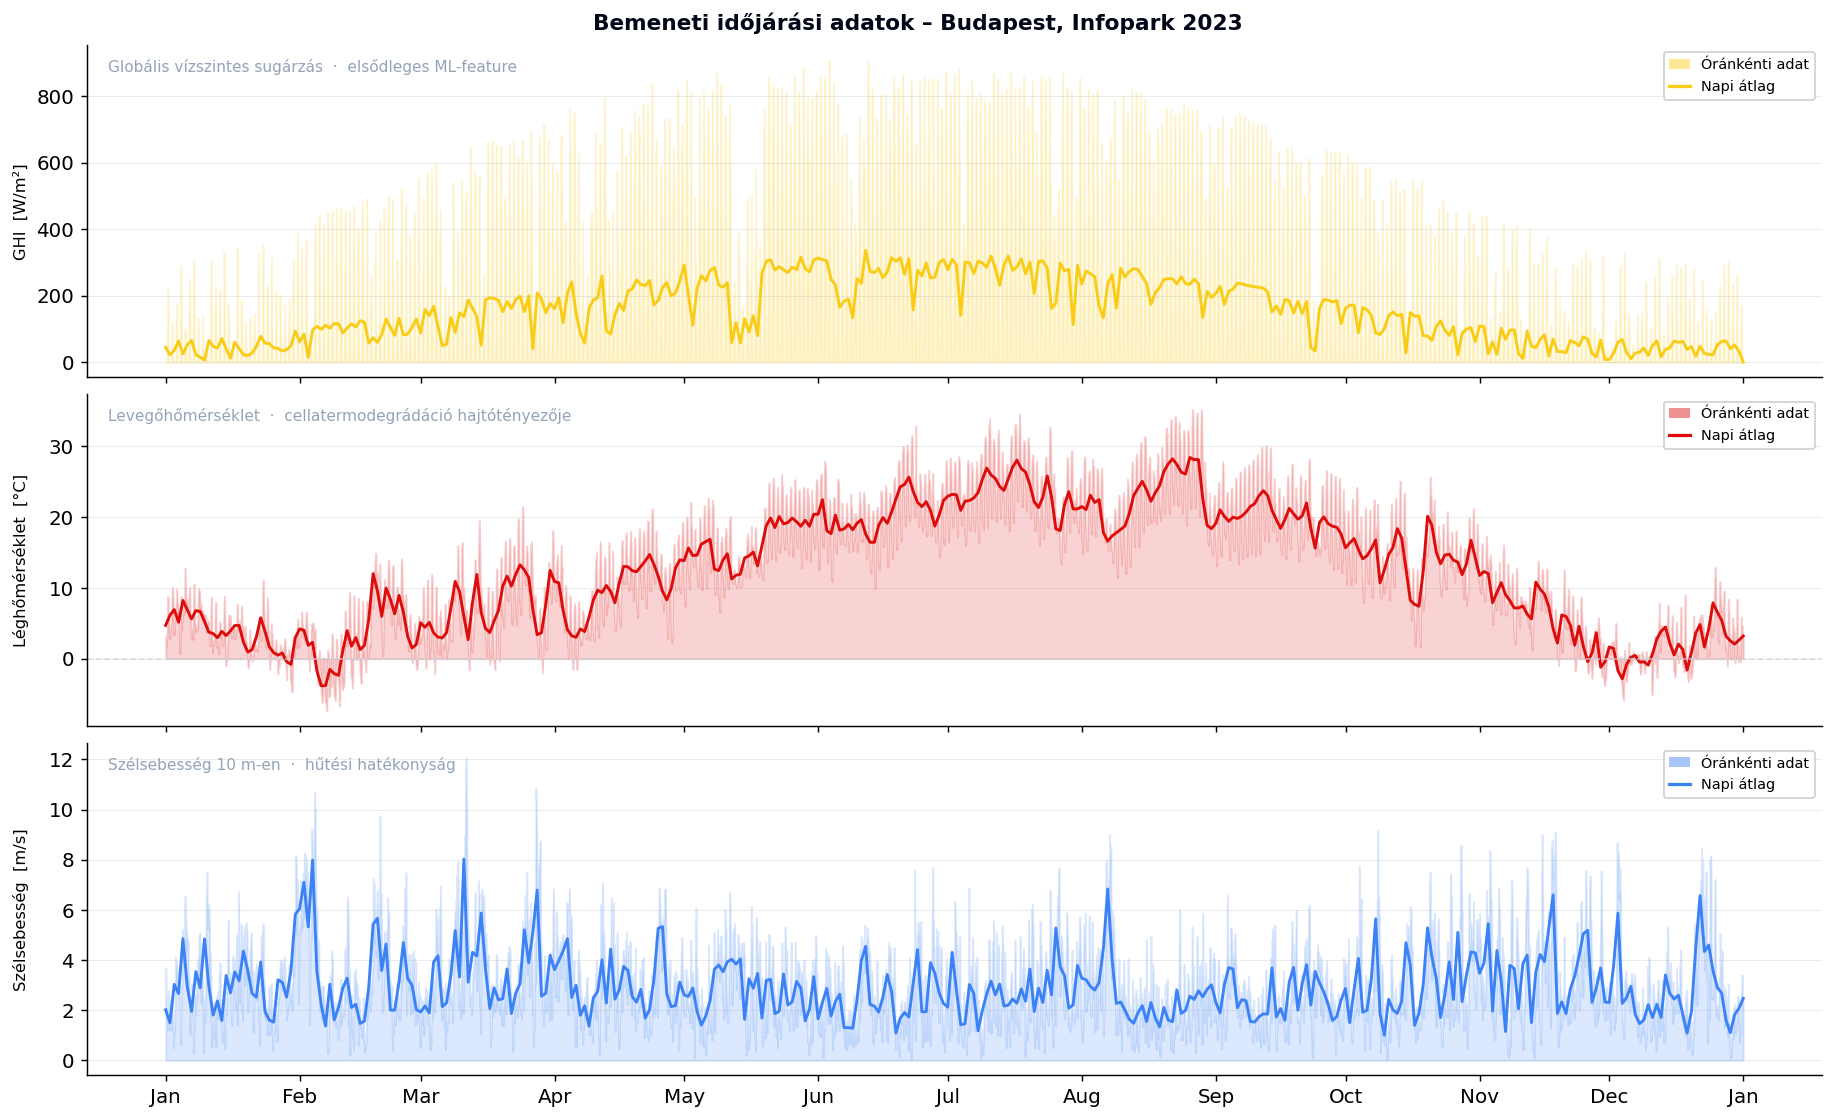

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from config import C_WEATHER, C_BASE, MPL_DEFAULTS
plt.rcParams.update(MPL_DEFAULTS)
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig, axes = plt.subplots(3, 1, figsize=(14, 8.5), sharex=True, layout="constrained")
fig.suptitle(
    "Bemeneti időjárási adatok – Budapest, Infopark 2023",
    fontsize=12, fontweight="bold", color=C_BASE["title"]
)

dw       = df_weather.copy()
dw_daily = dw.resample("D").mean()

panels = [
    ("ghi",        axes[0], C_WEATHER["ghi"],
     "GHI  [W/m²]",         "Globális vízszintes sugárzás  ·  elsődleges ML-feature"),
    ("temp_air",   axes[1], C_WEATHER["temp"],
     "Léghőmérséklet  [°C]", "Levegőhőmérséklet  ·  cellatermodegrádáció hajtótényezője"),
    ("wind_speed", axes[2], C_WEATHER["wind"],
     "Szélsebesség  [m/s]",  "Szélsebesség 10 m-en  ·  hűtési hatékonyság"),
]

for col, ax, color, ylabel, subtitle in panels:
    ax.fill_between(dw.index, dw[col], alpha=0.18, color=color)
    ax.plot(dw_daily.index, dw_daily[col], color=color, lw=1.6)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.text(0.012, 0.96, subtitle, transform=ax.transAxes,
            va="top", fontsize=8.5, color=C_BASE["text_lt"])
    ax.grid(axis="y", lw=0.4, alpha=0.35)
    ax.spines[["top", "right"]].set_visible(False)

    legend_handles = [
        Patch(facecolor=color, alpha=0.45, label="Óránkénti adat"),
        Line2D([0], [0], color=color, lw=1.8, label="Napi átlag"),
    ]
    ax.legend(handles=legend_handles, fontsize=8, loc="upper right",
              framealpha=0.85, handlelength=1.4)

axes[1].axhline(0, color=C_BASE["neutral"], lw=0.9, ls="--", alpha=0.8)  # fagyáshatár
axes[2].xaxis.set_major_locator(mdates.MonthLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
fig.align_ylabels(axes)
plt.show()


### ★

## 2. Szimuláció & Modell-validáció

A `pv_calculator.py` modul valósítja meg a feladatkiírás **Python teljesítményszámoló komponensét**. Beolvassa a `weather_data` táblát, a `pvlib` könyvtár segítségével elvégzi a teljes szimulációt, és az eredményeket a `pv_results` táblába írja.

### 2.1 Szimuláció futtatása

A számítás a következő napelemrendszerre vonatkozik (feladatkiírás + Trina Solar Vertex S DE09.08 adatlap):

<table style="width: 100%; border-collapse: collapse; font-family: sans-serif;">
  <thead>
    <tr style="background-color: #A81022; color: #ffffff; text-align: left;">
      <th style="padding: 10px; border: 1px solid #ddd;">Paraméter</th>
      <th style="padding: 10px; border: 1px solid #ddd;">Érték</th>
      <th style="padding: 10px; border: 1px solid #ddd;">Forrás</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #f9f9f9;">
      <td style="padding: 10px; border: 1px solid #ddd;">Panel típus</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Trina Solar Vertex S TSM-400 DE09.08</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Adatlap</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px; border: 1px solid #ddd;">Névleges teljesítmény</td>
      <td style="padding: 10px; border: 1px solid #ddd;">400 Wp / panel</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Adatlap (STC)</td>
    </tr>
    <tr style="background-color: #f9f9f9;">
      <td style="padding: 10px; border: 1px solid #ddd;">Panelek száma</td>
      <td style="padding: 10px; border: 1px solid #ddd;">10 db</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Feladatkiírás</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px; border: 1px solid #ddd;">Összes DC teljesítmény</td>
      <td style="padding: 10px; border: 1px solid #ddd;">4 000 Wp</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Számított</td>
    </tr>
    <tr style="background-color: #f9f9f9;">
      <td style="padding: 10px; border: 1px solid #ddd;">Dőlésszög</td>
      <td style="padding: 10px; border: 1px solid #ddd;">18°</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Feladatkiírás</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px; border: 1px solid #ddd;">Tájolás</td>
      <td style="padding: 10px; border: 1px solid #ddd;">180° (dél)</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Feltételezett optimum</td>
    </tr>
    <tr style="background-color: #f9f9f9;">
      <td style="padding: 10px; border: 1px solid #ddd;">Inverter max. teljesítmény</td>
      <td style="padding: 10px; border: 1px solid #ddd;">5 000 W</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Feladatkiírás</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px; border: 1px solid #ddd;">Modul hatásfok (η_m)</td>
      <td style="padding: 10px; border: 1px solid #ddd;">20,8 %</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Adatlap, TSM-400 sor</td>
    </tr>
    <tr style="background-color: #f4ccd0; font-weight: bold;">
      <td style="padding: 10px; border: 1px solid #ddd;">Hőmérsékleti együttható (γ_pdc)</td>
      <td style="padding: 10px; border: 1px solid #ddd;">−0,34 %/K</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Adatlap</td>
    </tr>
  </tbody>
</table>

<div style="background:#faf5ff;border-left:5px solid #7c3aed;padding:12px 16px;border-radius:4px;margin:12px 0">
<b>🎤 Tájolás feltételezés:</b> A déli tájolás (180°) egy <b>explicit feltételezés</b>, amelyet a feladatkiírás nem rögzít. A valós helyszínen az <b>épület orientációja</b>, helyi árnyékolási hatások (szomszédos épületek, fák) és egyéb tényezők eltérő azimutszeget indokolhatnak. Északi félgömbön a déltől keleti vagy nyugati irányban 45–90°-os eltérés az éves hozamot <b>10–20%-kal csökkentheti</b> – ez a 4 kWp-os rendszernél 570–1 140 kWh/év különbséget jelent. A tényleges érték csak helyszíni felméréssel (épülettájolás, árnyékolástérkép) határozható meg pontosan.
</div>

A kötelező `pvlib` függvények a pipeline sorrendjében:

1. `pvlib.temperature.pvsyst_cell()` – cellahőmérséklet a POA irradiancia, léghőmérséklet és szélsebesség alapján
2. `pvlib.pvsystem.pvwatts_dc()` – DC teljesítmény hőmérsékleti korrekcióval
3. `pvlib.inverter.pvwatts()` – AC teljesítmény az inverter hatásfok és clipping modellezésével

In [6]:
from pv_calculator import run_pv_simulation, get_pv_dataframe, PDC0_TOTAL, PDC0_INV

df_pv = run_pv_simulation()   # számítás + pv_results tábla feltöltése

04:42:49  INFO      A pv_results táblában már 8760 sor van – számítás kihagyva (force_reload=True-val kényszeríthető újra).
04:42:49  INFO      Rendszer-veszteség alkalmazva: derate factor = 0.8679, residual loss = 13.21%
04:42:49  INFO      pv_results betöltve: 8760 sor, 2023-01-01T01:00:00+01:00 – 2024-01-01T00:00:00+01:00


### 2.2 Eredmény ellenőrzése

Gyors sanity check: sorok száma, időhatárok, NaN-értékek és a `p_ac` fizikai értékkészlete. A `p_ac` minimuma 0 kell legyen (a negatív inverter-szivárgási értékeket a kód nullára vágja), maximuma az inverter 5 kW-os clipping határán vagy alatt.

In [7]:
print(f"Sorok száma    : {len(df_pv)}")
print(f"Első időpont   : {df_pv.index[0]}")
print(f"Utolsó időpont : {df_pv.index[-1]}")
print()
print("NaN értékek:")
print(df_pv.isna().sum())
print()
print(f"p_ac  min : {df_pv['p_ac'].min():.4f} W   (negatív nem lehet)")
print(f"p_ac  max : {df_pv['p_ac'].max():.1f} W")
print(f"p_dc  max : {df_pv['p_dc'].max():.1f} W")
print()
print("Első nappali sorok (p_ac > 0):")
print(df_pv[df_pv["p_ac"] > 0].head(3).round(2))

Sorok száma    : 8760
Első időpont   : 2023-01-01 01:00:00+01:00
Utolsó időpont : 2024-01-01 00:00:00+01:00

NaN értékek:
poa_global       0
temp_cell        0
p_dc             0
p_ac             0
p_ac_net         0
energy_loss_w    0
dtype: int64

p_ac  min : 0.0000 W   (negatív nem lehet)
p_ac  max : 3552.8 W
p_dc  max : 3692.6 W

Első nappali sorok (p_ac > 0):
                           poa_global  temp_cell     p_dc     p_ac  p_ac_net  \
timestamp                                                                      
2023-01-01 09:00:00+01:00       80.46       6.74   341.82   305.91    265.51   
2023-01-01 10:00:00+01:00      149.56      10.09   628.56   586.59    509.12   
2023-01-01 11:00:00+01:00      293.78      15.63  1212.56  1156.62   1003.86   

                           energy_loss_w  
timestamp                                 
2023-01-01 09:00:00+01:00          40.40  
2023-01-01 10:00:00+01:00          77.48  
2023-01-01 11:00:00+01:00         152.76  


<a id="viz-scatter"></a>

### 2.3 DC modell-validáció

A szimulációs eredmények hitelességének alapja. A két panel együtt mutatja a pvlib  lépésének viselkedését.

**Bal panel – teljes adatfelhő:** az összes nappali adatpont () POA-irradiancia szerint színezve (plasma colormap). A sárga–kék gradiens megmutatja, hogy erős sugárzásnál (sárga) az azonos hőmérsékletű pontokhoz nagyobb DC teljesítmény tartozik – a POA és a hőmérséklet együttes hatása itt egyetlen felhőben látható.

**Jobb panel – binelt regresszió:** ugyanezek a pontok négy szűk POA-tartományban (±50 W/m² bin) csoportosítva. Binenként lineáris regresszió méri a hőmérsékleti meredekséget. A magasabb POA-s binek (500–900 W/m²) γ értéke az adatlap −0,34 %/K referenciáját közelíti; az alacsony (300 W/m²) bin szignifikánsan eltér (mért: ~−0,15 %/K), ami fizikailag várható: kis irradiancánál a cellahőmérséklet-emelkedés abszolút értéke csekély, a regresszió torzít.

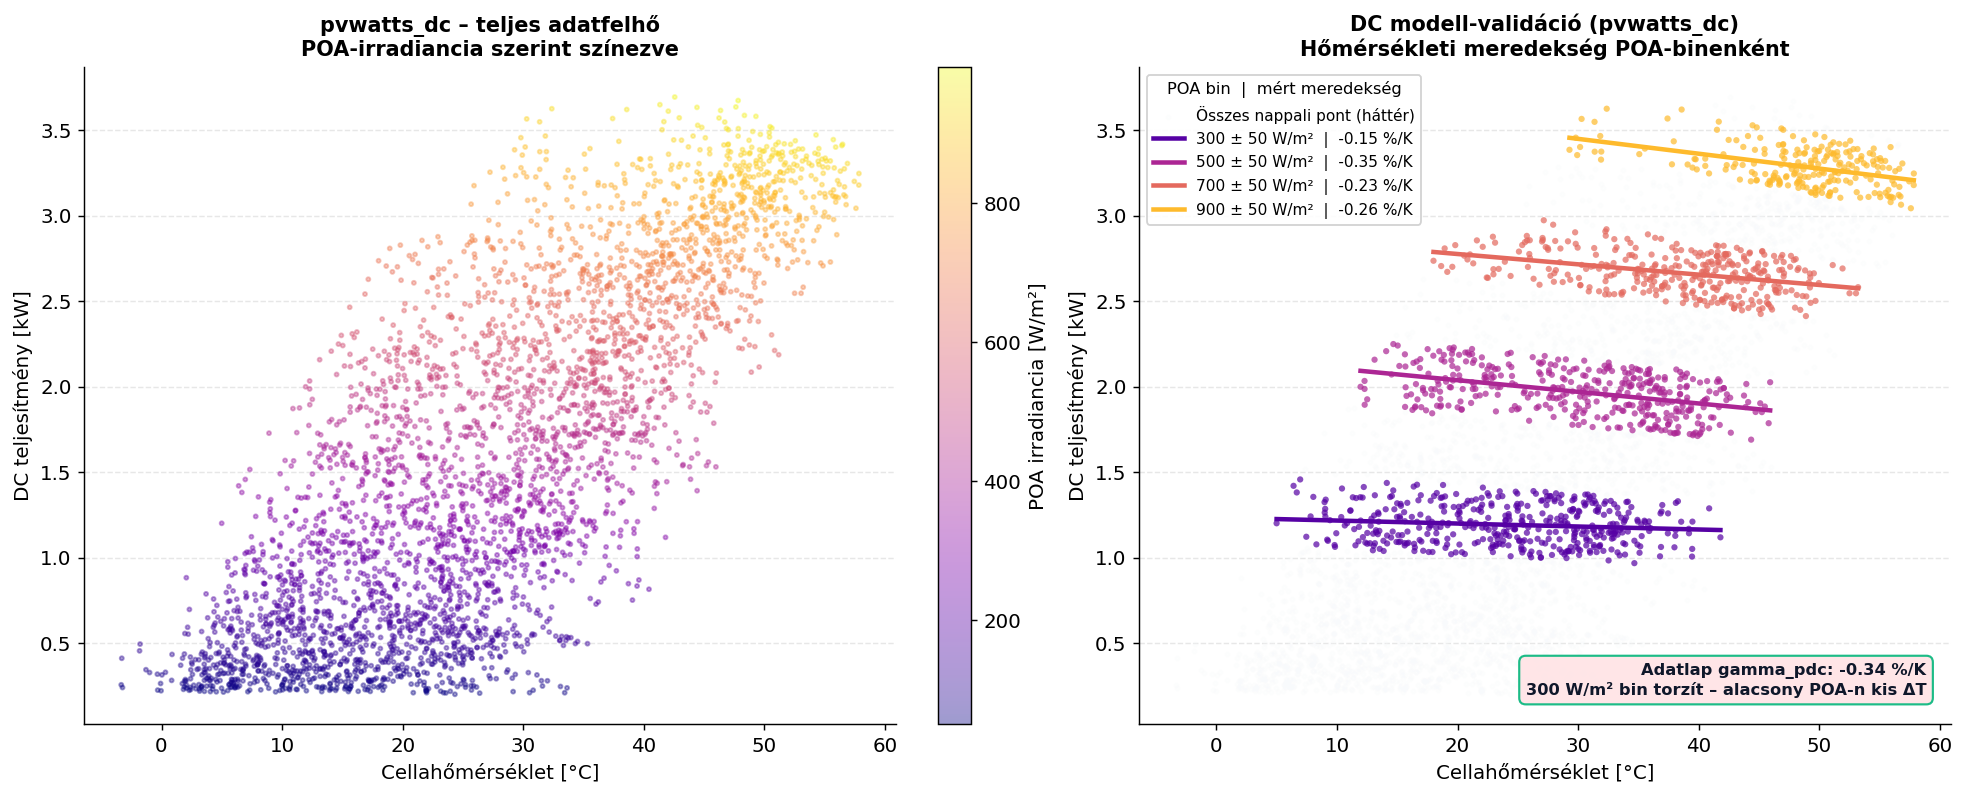


POA-binenként mért gamma_pdc:
  300 ± 50 W/m²         : -0.146 %/K  (n = 432)
  500 ± 50 W/m²         : -0.347 %/K  (n = 392)
  700 ± 50 W/m²         : -0.227 %/K  (n = 339)
  900 ± 50 W/m²         : -0.265 %/K  (n = 226)
  Adatlap referencia    : -0.340 %/K


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from config import GAMMA_PDC, C_BASE, MPL_DEFAULTS
plt.rcParams.update(MPL_DEFAULTS)

daytime = df_pv[df_pv["poa_global"] > 50].copy()

poa_bins = [
    (250, 350, "300 ± 50 W/m²"),
    (450, 550, "500 ± 50 W/m²"),
    (650, 750, "700 ± 50 W/m²"),
    (850, 950, "900 ± 50 W/m²"),
]
bin_colors    = plt.cm.plasma(np.linspace(0.15, 0.85, len(poa_bins)))
gamma_pdc_pct = GAMMA_PDC * 100

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 6), layout="constrained")

# ── Bal panel: teljes adatfelhő – POA-irradiancia szerint színezve ────────────────────
sc = axL.scatter(daytime["temp_cell"], daytime["p_dc"] / 1000,
                 c=daytime["poa_global"], cmap="plasma",
                 alpha=0.40, s=5, rasterized=True, zorder=2)
plt.colorbar(sc, ax=axL).set_label("POA irradiancia [W/m²]")
axL.set_xlabel("Cellahőmérséklet [°C]")
axL.set_ylabel("DC teljesítmény [kW]")
axL.set_title(
    "pvwatts_dc – teljes adatfelhő" + chr(10)
    + "POA-irradiancia szerint színezve",
    fontweight="bold", fontsize=11.5)
axL.yaxis.grid(True, alpha=0.3, linestyle="--")
axL.set_axisbelow(True)

# ── Jobb panel: POA-binenként regresszió ─────────────────────────────────────
axR.scatter(daytime["temp_cell"], daytime["p_dc"] / 1000,
            c=C_BASE["bg"], alpha=0.18, s=4, rasterized=True, zorder=1,
            label="Összes nappali pont (háttér)")

slope_results = []
for (lo, hi, label), color in zip(poa_bins, bin_colors):
    subset = daytime[(daytime["poa_global"] >= lo) & (daytime["poa_global"] < hi)]
    if len(subset) < 5:
        continue
    x = subset["temp_cell"].values
    y = subset["p_dc"].values / 1000
    axR.scatter(x, y, color=color, alpha=0.70, s=12, zorder=3, edgecolors="none")
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 50)
    y_mid  = slope * np.median(x) + intercept
    pct_k  = (slope / y_mid) * 100 if y_mid > 0 else 0.0
    axR.plot(x_line, slope * x_line + intercept,
             color=color, linewidth=2.5, zorder=4,
             label=f"{label}  |  {pct_k:+.2f} %/K")
    slope_results.append((label, pct_k, len(subset)))

_ann = (f"Adatlap gamma_pdc: {gamma_pdc_pct:+.2f} %/K"
        + chr(10) + "300 W/m² bin torzít – alacsony POA-n kis ΔT")
axR.text(0.97, 0.04, _ann,
         transform=axR.transAxes, fontsize=9, ha="right", va="bottom",
         fontweight="bold", color=C_BASE["text_dk"],
         bbox=dict(boxstyle="round,pad=0.4", facecolor=C_BASE["ann_fill"],
                   edgecolor=C_BASE["ann_edge"], linewidth=1.2, alpha=0.95))

axR.set_xlabel("Cellahőmérséklet [°C]")
axR.set_ylabel("DC teljesítmény [kW]")
axR.set_title(
    "DC modell-validáció (pvwatts_dc)" + chr(10)
    + "Hőmérsékleti meredekség POA-binenként",
    fontweight="bold", fontsize=11.5)
axR.legend(framealpha=0.88, fontsize=8.5,
           title="POA bin  |  mért meredekség", title_fontsize=9,
           loc="upper left")
axR.yaxis.grid(True, alpha=0.3, linestyle="--")
axR.set_axisbelow(True)

plt.show()

print("")
print("POA-binenként mért gamma_pdc:")
for label, pct, n in slope_results:
    print(f"  {label:22s}: {pct:+.3f} %/K  (n = {n})")
print(f"  Adatlap referencia    : {gamma_pdc_pct:+.3f} %/K")

### ★

### 2.4 Cellahőmérséklet és termodegradáció

A `pvlib.temperature.pvsyst_cell` a panel energiamérlegéből számítja a tényleges cellahőmérsékletet (POA + T\_air + szél). A T\_cell közvetlenül rontja a DC teljesítményt a **hőmérsékleti együtthatón** keresztül:

> **ΔP/P = γ × (T\_cell − 25 °C),   γ = −0,34 %/°C** _(Trina Vertex S adatlap)_

Nyáron a cellahőmérséklet elérheti az 55–65 °C-ot, ami ~10–14%-os termodegradációt jelent. Ez a rendszer **legjelentősebb nemlineáris veszteségforrása** — és egyben az első érv az ML mellett: egy prediktív modell a T\_cell és POA kölcsönhatását közvetlenül tanulja meg, nem kell fizikai modellbe kódolni.

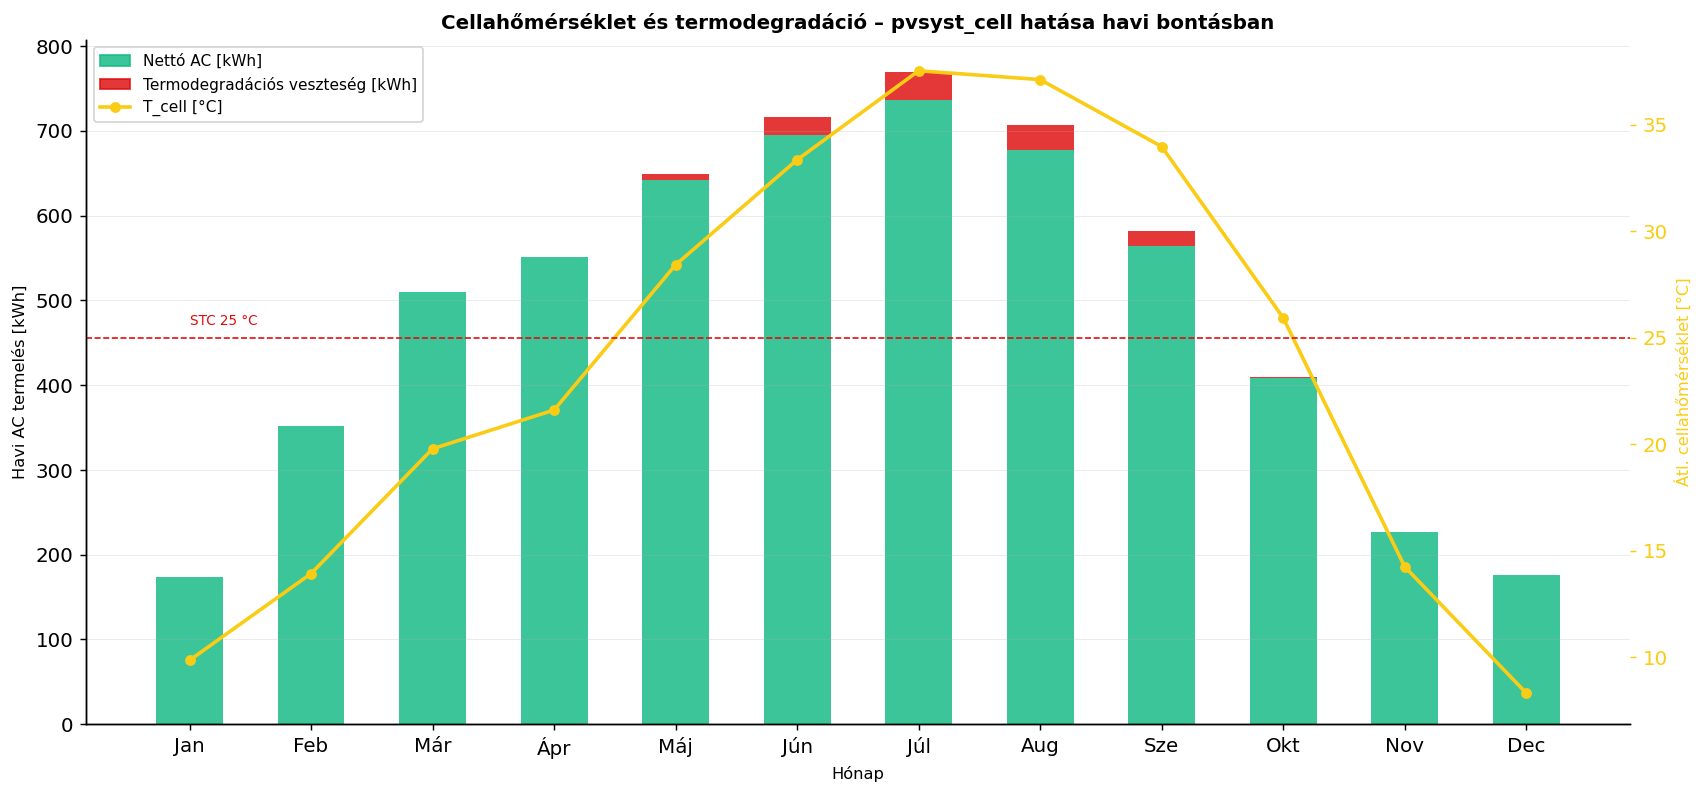

In [9]:
import matplotlib.pyplot as plt
from config import GAMMA_PDC, TEMP_REF, C_THERMO, C_BASE, MPL_DEFAULTS
plt.rcParams.update(MPL_DEFAULTS)

MONTH_HU = ["Jan","Feb","Már","Ápr","Máj","Jún",
            "Júl","Aug","Sze","Okt","Nov","Dec"]

# groupby(month) → mindig pontosan 12 érték, nincs határeffektus
daylight      = df_pv[df_pv["poa_global"] > 10]
monthly_tcell = daylight["temp_cell"].groupby(daylight.index.month).mean()
monthly_pac   = df_pv["p_ac"].groupby(df_pv.index.month).sum() / 1000  # kWh

derating     = 1 + GAMMA_PDC * (monthly_tcell - TEMP_REF)
thermal_loss = ((monthly_pac / derating) - monthly_pac).clip(lower=0)

fig, ax1 = plt.subplots(figsize=(13, 6), layout="constrained")
ax2 = ax1.twinx()

x = range(12)
ax1.bar(x, monthly_pac.values,   color=C_THERMO["ac"], alpha=0.82, width=0.55, label="Nettó AC [kWh]")
ax1.bar(x, thermal_loss.values, bottom=monthly_pac.values,
        color=C_THERMO["loss"], alpha=0.82, width=0.55, label="Termodegradációs veszteség [kWh]")
line, = ax2.plot(x, monthly_tcell.values, color=C_THERMO["temp"], lw=2, marker="o", ms=5,
                 label="Átl. cellahőmérséklet (nappali) [°C]")
ax2.axhline(TEMP_REF, color=C_THERMO["stc_ref"], lw=0.9, ls="--")
ax2.text(0, TEMP_REF + 0.6, "STC 25 °C", fontsize=7.5, color=C_THERMO["stc_ref"])

ax1.set_xlabel("Hónap", fontsize=9)
ax1.set_ylabel("Havi AC termelés [kWh]", fontsize=9)
ax2.set_ylabel("Átl. cellahőmérséklet [°C]", fontsize=9, color=C_THERMO["temp"])
ax2.tick_params(axis="y", colors=C_THERMO["temp"])
ax1.set_xticks(x)
ax1.set_xticklabels(MONTH_HU)
ax1.set_ylim(bottom=0)
ax1.grid(axis="y", lw=0.4, alpha=0.35)
ax1.spines[["top", "right"]].set_visible(False)

handles = [plt.Rectangle((0,0),1,1,color=C_THERMO["ac"],alpha=0.82),
           plt.Rectangle((0,0),1,1,color=C_THERMO["loss"],alpha=0.82), line]
ax1.legend(handles, ["Nettó AC [kWh]","Termodegradációs veszteség [kWh]","T_cell [°C]"],
           loc="upper left", fontsize=8.5)
ax1.set_title("Cellahőmérséklet és termodegradáció – pvsyst_cell hatása havi bontásban",
              fontsize=11, fontweight="bold")
plt.show()

### ★

## 3. Termelési mintázat

A validált modell által produkált energia időbeli szerkezete szezonális és napszaki bontásban.

<a id="viz-hoterkep"></a>

### 3.1 Hónap × napszak hőtérkép

Az átlagos nettó AC teljesítmény [W] pivot-táblája. A legkompaktabb nézet a szezonális és napszaki mintázat együttes megértéséhez: téli csúcs délben ~200–300 W, nyári ~400–500 W, a reggeli/esti rampa szezonálisan tolódik.

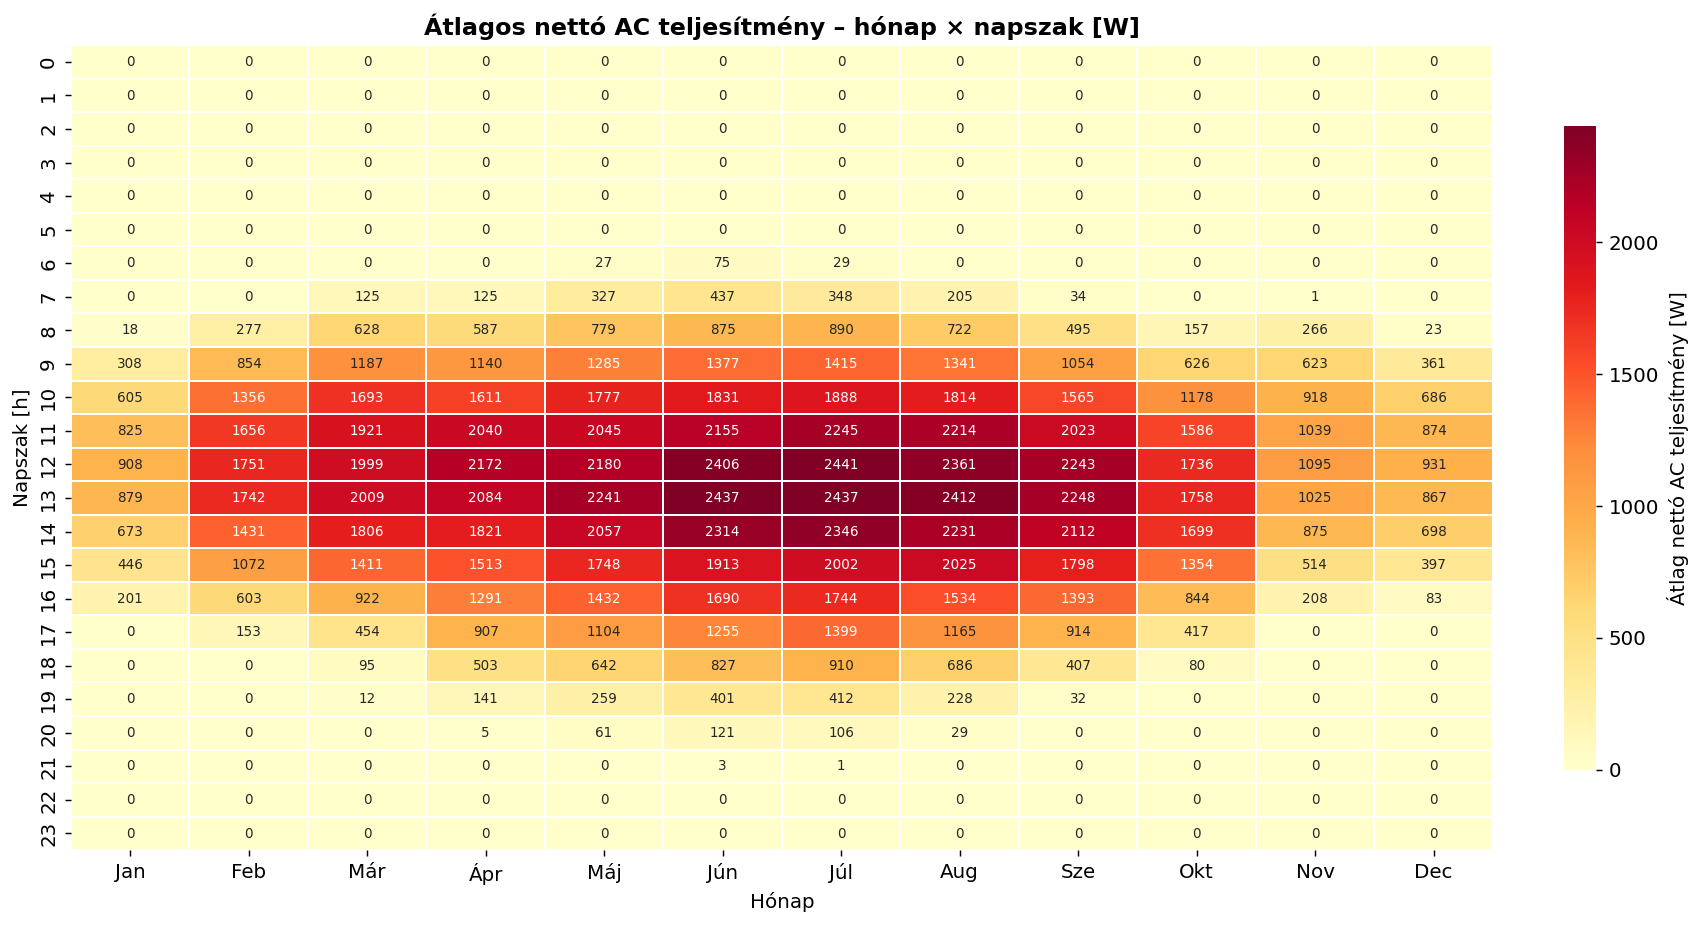

In [10]:
import math
from config import C_HEATMAP, MPL_DEFAULTS
plt.rcParams.update(MPL_DEFAULTS)
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from config import DETAILED_SYSTEM_LOSSES

MONTH_HU = [
    "Jan", "Feb", "Már", "Ápr", "Máj", "Jún",
    "Júl", "Aug", "Sze", "Okt", "Nov", "Dec",
]
derate_live = math.prod(1.0 - v for v in DETAILED_SYSTEM_LOSSES.values())

pivot = df_pv.assign(
    p_ac_net=df_pv["p_ac"] * derate_live,
    _month=df_pv.index.month,
    _hour=df_pv.index.hour,
).pivot_table(values="p_ac_net", index="_hour", columns="_month", aggfunc="mean")
pivot.columns = MONTH_HU
pivot.index.name = "Napszak [h]"

fig, ax = plt.subplots(figsize=(13, 7), layout="constrained")
sns.heatmap(
    pivot, ax=ax, cmap="YlOrRd", linewidths=0.2,
    cbar_kws={"label": "Átlag nettó AC teljesítmény [W]", "shrink": 0.8},
    annot=True, fmt=".0f", annot_kws={"size": 7.5},
)
ax.set_title("Átlagos nettó AC teljesítmény – hónap × napszak [W]", fontweight="bold")
ax.set_xlabel("Hónap")

plt.show()

### ★

<a id="viz-idosor"></a>

### 3.2 Napi termelés – éves idősor

Napi összesített nettó AC termelés [kWh] és 14 napos mozgóátlag. Zöld: növekvő félév (jan. 1. – jún. 21.), piros: csökkenő félév (jún. 21. – dec. 21.). A nyári szórás az időjárás-variabilitást mutatja.

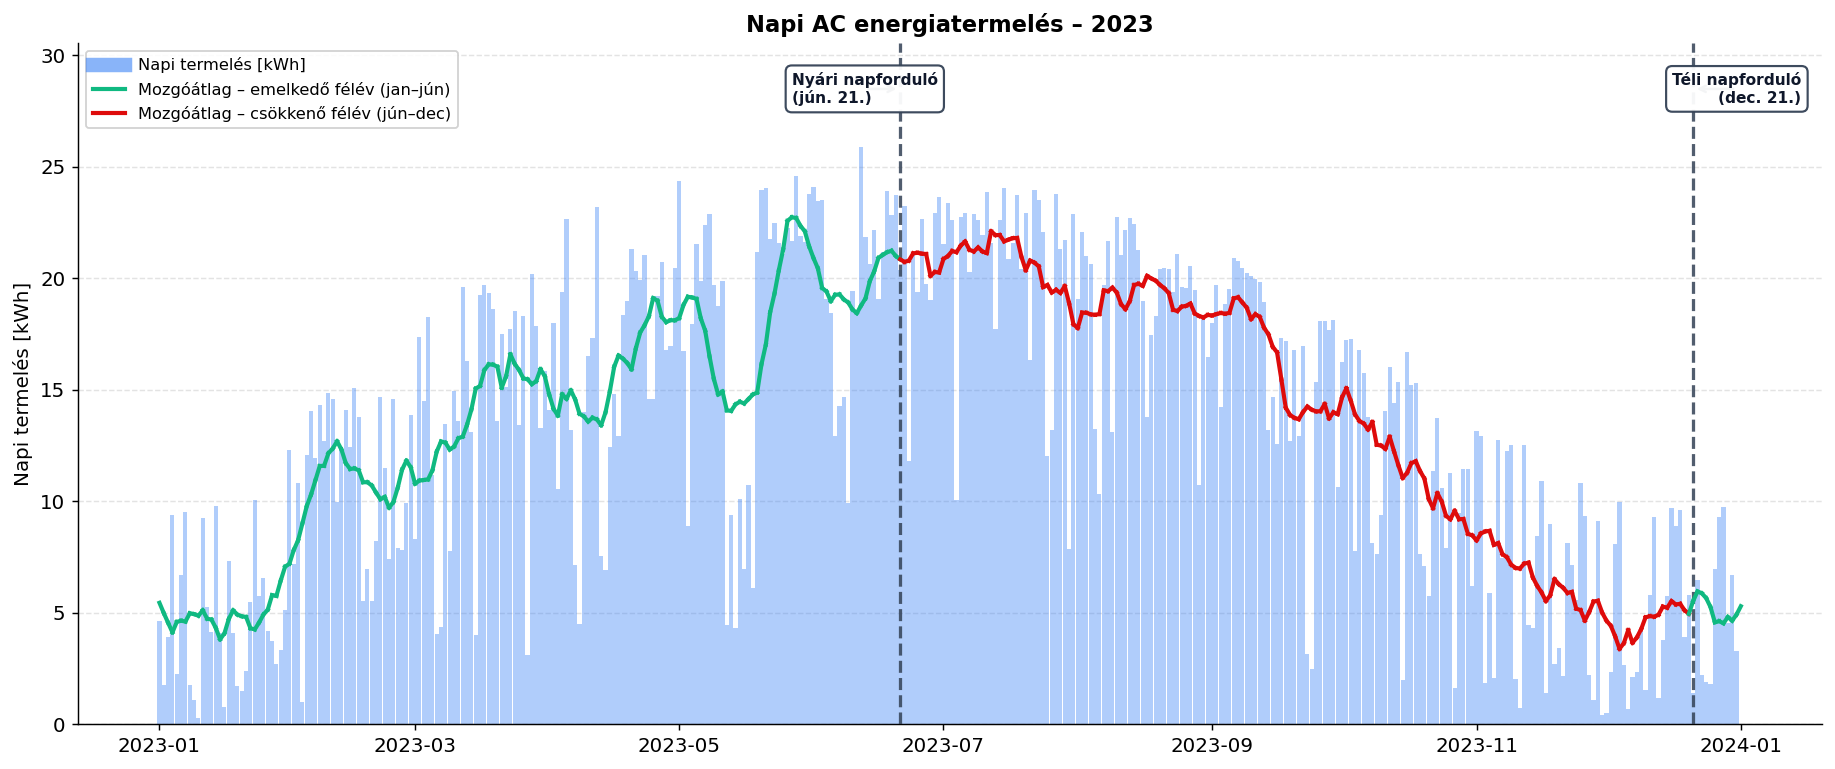

In [11]:
import datetime
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import math
from config import YEAR, TIMEZONE, DETAILED_SYSTEM_LOSSES, C_DAILY, C_BASE, MPL_DEFAULTS
plt.rcParams.update(MPL_DEFAULTS)

# ── Adatok előkészítése ───────────────────────────────────────────────────────
derate_live = math.prod(1.0 - v for v in DETAILED_SYSTEM_LOSSES.values())
daily_kwh  = (df_pv["p_ac"] * derate_live).resample("D").sum() / 1000
rolling_14 = daily_kwh.rolling(14, center=True, min_periods=7).mean()

# Napfordulók dátumai – YEAR-ből és TIMEZONE-ból számítva, nem hardcode-olva
summer_solstice = pd.Timestamp(datetime.date(YEAR,  6, 21)).tz_localize(TIMEZONE)
winter_solstice = pd.Timestamp(datetime.date(YEAR, 12, 21)).tz_localize(TIMEZONE)

# ── Annotációs színséma – semleges slate, nem verseng az adatelemekkel ───────
SOLSTICE_COLOR      = C_BASE["neutral_dk"]
SOLSTICE_TEXT_COLOR = C_BASE["text_dk"]
SOLSTICE_BG_COLOR   = C_BASE["bg_light"]

fig, ax = plt.subplots(figsize=(14, 5.8), layout="constrained")

# ── Napi termelés ─────────────────────────────────────────────────────────────
ax.bar(daily_kwh.index, daily_kwh.values,
       alpha=0.40, color=C_DAILY["ac"], width=0.95,
       label="Napi termelés [kWh]")

# ── 14 napos mozgóátlag – napforduló alapú színezés ──────────────────────────
# Emelkedő félév: jan. 1. – jún. 21. (téli napfordulótól nyári napfordulóig)
# Csökkenő félév: jún. 21. – dec. 21. (nyári napfordulótól téli napfordulóig)
for i in range(1, len(rolling_14)):
    if pd.isna(rolling_14.iloc[i]) or pd.isna(rolling_14.iloc[i - 1]):
        continue
    ts = rolling_14.index[i]
    color = C_DAILY["rising"] if ts <= summer_solstice or ts >= winter_solstice \
            else C_DAILY["falling"]
    ax.plot(
        [rolling_14.index[i - 1], rolling_14.index[i]],
        [rolling_14.iloc[i - 1], rolling_14.iloc[i]],
        color=color, linewidth=2.3, zorder=5)

# ── Napfordulók – az emelkedő és csökkenő félév határai ──────────────────────
solstices = [
    (summer_solstice, "Nyári napforduló\n(jún. 21.)", "left",  -60),
    (winter_solstice, "Téli napforduló\n(dec. 21.)",  "right",  60),
]
for ts, label, ha, x_offset in solstices:
    ax.axvline(ts, color=SOLSTICE_COLOR, linestyle="--",
               linewidth=1.8, alpha=0.85, zorder=3)
    ax.annotate(
        label,
        xy=(ts, daily_kwh.max() * 1.10),
        xytext=(x_offset, 0), textcoords="offset points",
        ha=ha, va="center", fontsize=8.5,
        color=SOLSTICE_TEXT_COLOR, fontweight="bold",
        arrowprops=dict(arrowstyle="->", color=SOLSTICE_COLOR,
                        lw=1.4, connectionstyle="arc3,rad=0.0"),
        bbox=dict(boxstyle="round,pad=0.4", facecolor=SOLSTICE_BG_COLOR,
                  edgecolor=SOLSTICE_COLOR, linewidth=1.2, alpha=0.95),
        zorder=7)

# ── Legend – proxy artistekkel a kétszínű mozgóátlaghoz ─────────────────────
legend_elements = [
    Line2D([0], [0], color=C_DAILY["ac"], alpha=0.6, linewidth=8,
           label="Napi termelés [kWh]"),
    Line2D([0], [0], color=C_DAILY["rising"], linewidth=2.3,
           label="Mozgóátlag – emelkedő félév (jan–jún)"),
    Line2D([0], [0], color=C_DAILY["falling"], linewidth=2.3,
           label="Mozgóátlag – csökkenő félév (jún–dec)"),
]
ax.legend(handles=legend_elements, framealpha=0.88,
          loc="upper left", fontsize=9)

ax.set_ylabel("Napi termelés [kWh]")
ax.set_title(
    f"Napi AC energiatermelés – {YEAR}",
    fontweight="bold", fontsize=12.5)
ax.set_ylim(0, daily_kwh.max() * 1.18)
ax.yaxis.grid(True, alpha=0.35, linestyle="--")
ax.set_axisbelow(True)

plt.show()

### ★

## 4. Veszteségszerkezet

A validált modell alapján: mennyi energia veszett el, mikor és miért.

<a id="viz-kpi"></a>

### 4.1 Havi termelési összefoglaló

A három KPI kártya az éves headline-számokat mutatja: nettó AC termelés, össz. veszteség az STC DC potenciálhoz képest, Performance Ratio (IEC 61724-1).

A havi bar az energiaútvonal teljes veszteségszerkezetét tárja fel – az oszlopok alja a hálózatra kerülő nettó AC, teteje az STC DC potenciál. Szelvények alulról: **nettó AC → rendszerveszteség → inverterveszteség → clipping → hőmérsékleti veszteség** (csak T > 25 °C hónapokban). Az oszlopok feletti negatív értékek az össz. veszteségeket mutatják kWh-ban.

(0.0, 1072.5135510174186)

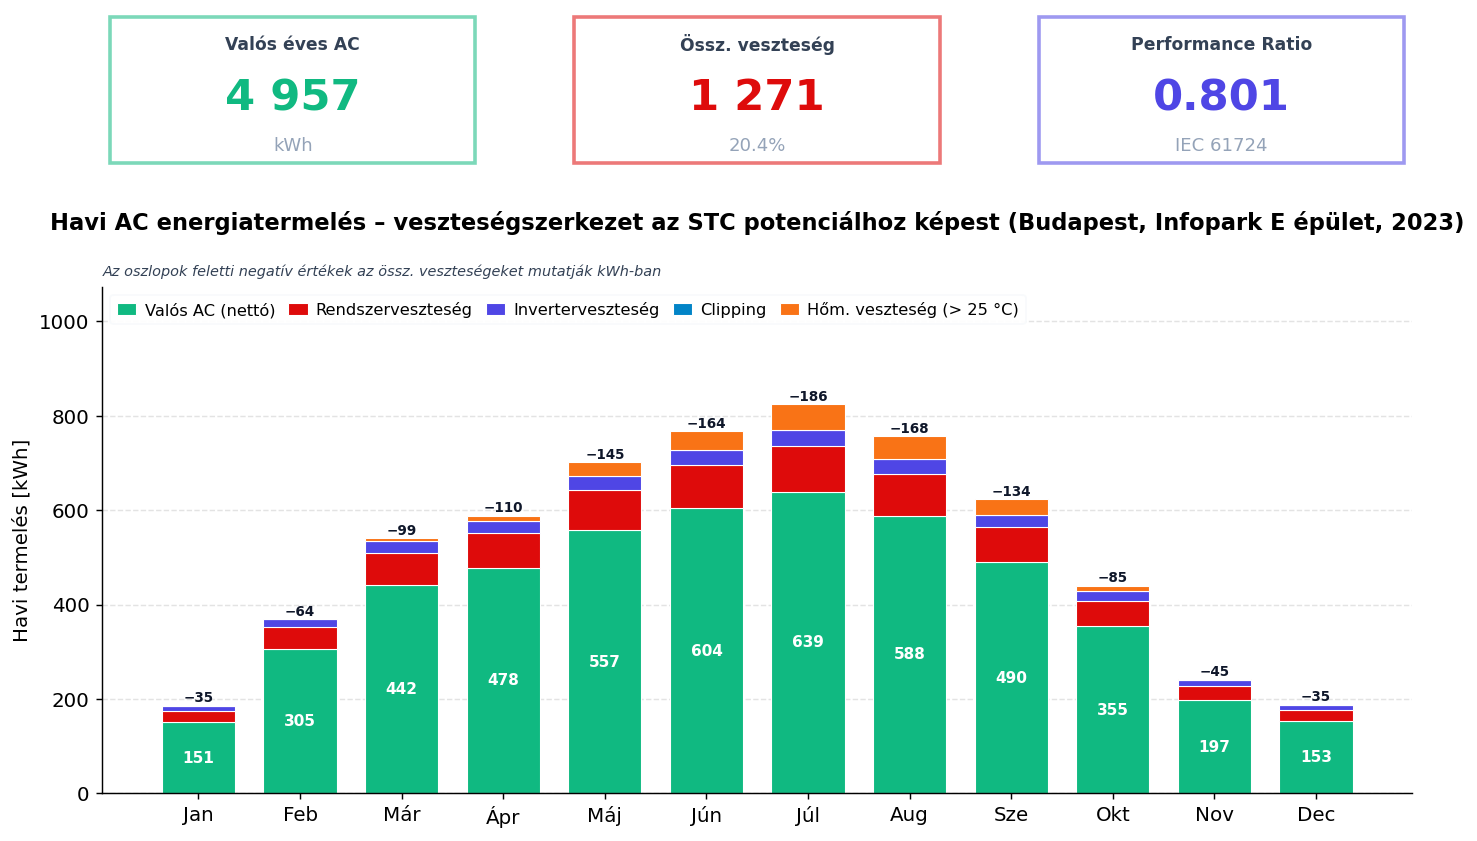

In [12]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from config import LOCATION_NAME, YEAR, DETAILED_SYSTEM_LOSSES, GAMMA_PDC, TEMP_REF
from pv_calculator import PDC0_TOTAL, PDC0_INV

MONTH_HU = [
    "Jan", "Feb", "Már", "Ápr", "Máj", "Jún",
    "Júl", "Aug", "Sze", "Okt", "Nov", "Dec",
]

from config import C_WATERFALL, C_BASE, MPL_DEFAULTS
plt.rcParams.update(MPL_DEFAULTS)

PDC0_KWP    = PDC0_TOTAL / 1000
derate_live = math.prod(1.0 - v for v in DETAILED_SYSTEM_LOSSES.values())

# ── Óránkénti veszteségkomponensek (adatvezérelten, df_pv-ből) ──────────────
p_ac_net_live = df_pv["p_ac"] * derate_live

# STC DC potenciál: amit a rendszer 25 °C-on termelne (az oszlopok teteje)
p_dc_stc = df_pv["poa_global"] / 1000 * PDC0_TOTAL

# 1. Hőmérsékleti veszteség: STC DC és tényleges DC különbsége
#    Téli hónapokban (temp_cell < TEMP_REF) ez negatív → 0-ra vágva (téli hőnyereség nem látható)
temp_loss_h = (p_dc_stc - df_pv["p_dc"]).clip(lower=0)

# 2. Clipping: p_dc > inverter névleges DC kapacitása (ILR=0.80 → várhatóan ~0)
clipping_h = (df_pv["p_dc"] - PDC0_INV).clip(lower=0)

# 3. Inverterveszteség: DC → AC konverziós veszteség
inverter_loss_h = (df_pv["p_dc"] - clipping_h - df_pv["p_ac"]).clip(lower=0)

# 4. Rendszerveszteség: p_ac → nettó AC (DETAILED_SYSTEM_LOSSES derate)
system_loss_h = (df_pv["p_ac"] - p_ac_net_live).clip(lower=0)

# ── Havi kWh összesítők ───────────────────────────────────────────────────────
def _monthly_kwh(s):
    return s.groupby(s.index.month).sum() / 1000

monthly_kwh_real  = _monthly_kwh(p_ac_net_live)
monthly_sys_loss  = _monthly_kwh(system_loss_h)
monthly_inv_loss  = _monthly_kwh(inverter_loss_h)
monthly_clipping  = _monthly_kwh(clipping_h)
monthly_temp_loss = _monthly_kwh(temp_loss_h)

# ── KPI mutatók ───────────────────────────────────────────────────────────────
annual_kwh_real  = monthly_kwh_real.sum()
annual_kwh_ideal = df_pv["p_ac"].sum() / 1000
annual_total_loss_kwh = (monthly_sys_loss + monthly_inv_loss
                         + monthly_clipping + monthly_temp_loss).sum()
annual_stc_kwh        = annual_kwh_real + annual_total_loss_kwh
annual_total_loss_pct = annual_total_loss_kwh / annual_stc_kwh * 100
annual_h_poa     = df_pv["poa_global"].sum() / 1000
annual_pr        = annual_kwh_real / (PDC0_KWP * annual_h_poa)

kpi_data = [
    ("Valós éves AC",     f"{annual_kwh_real:,.0f}".replace(",", " "), "kWh",       C_WATERFALL["ac"]),
    ("Össz. veszteség",   f"{annual_total_loss_kwh:,.0f}".replace(",", " "),
     f"{annual_total_loss_pct:.1f}%",                                                C_WATERFALL["loss"]),
    ("Performance Ratio", f"{annual_pr:.3f}",                         "IEC 61724", C_WATERFALL["inv"]),
]

# ── Layout ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 7.8))
gs  = GridSpec(2, 3, figure=fig, height_ratios=[1, 3.2], hspace=0.35, wspace=0.22)

for i, (label, value, unit, color) in enumerate(kpi_data):
    ax_k = fig.add_subplot(gs[0, i])
    ax_k.set_facecolor(C_BASE["bg_light"])
    for sp in ax_k.spines.values():
        sp.set_visible(False)
    ax_k.set_xticks([]); ax_k.set_yticks([])
    ax_k.text(0.5, 0.80, label, ha="center", va="center", fontsize=9.5,
              fontweight="bold", color=C_BASE["neutral_dk"], transform=ax_k.transAxes)
    ax_k.text(0.5, 0.46, value, ha="center", va="center", fontsize=24,
              fontweight="bold", color=color,   transform=ax_k.transAxes)
    ax_k.text(0.5, 0.16, unit,  ha="center", va="center", fontsize=10,
              color=C_BASE["text_lt"],   transform=ax_k.transAxes)
    ax_k.add_patch(plt.Rectangle(
        (0.02, 0.05), 0.96, 0.92, transform=ax_k.transAxes,
        fill=False, edgecolor=color, linewidth=2, alpha=0.55))

# ── Havi stackelt barchart ─────────────────────────────────────────────────────
# Szekvencia alulról felfelé: AC nettó → rendszerveszteség → inverter → clipping → hőmérséklet
# Szín best practice: zöld (termelés), piros (rendszer), amber (elektromos), indigo (tervezési),
# kék (fizikai/hőmérsékleti) – Tailwind CSS perceptuálisan kiegyensúlyozott paletta
SEGMENTS = [
    (monthly_kwh_real,  C_WATERFALL["ac"], "Valós AC (nettó)"),
    (monthly_sys_loss,  C_WATERFALL["loss"], "Rendszerveszteség"),
    (monthly_inv_loss,  C_WATERFALL["inv"], "Inverterveszteség"),
    (monthly_clipping,  C_WATERFALL["clip"], "Clipping"),
    (monthly_temp_loss, C_WATERFALL["temp"], "Hőm. veszteség (> 25 °C)"),
]

width = 0.72
ax    = fig.add_subplot(gs[1, :])
x     = np.arange(1, 13)

bottoms = np.zeros(12)
for data, color, label in SEGMENTS:
    vals = data.values
    bars = ax.bar(x, vals, width, bottom=bottoms,
                  label=label, color=color, edgecolor="white", linewidth=0.6)
    # Zöld szelvény: kWh felirat középre, fehér félkövér
    if label == "Valós AC (nettó)":
        for xi, (v, bot) in enumerate(zip(vals, bottoms)):
            if v > 45:
                ax.text(xi + 1, bot + v / 2, f"{v:.0f}",
                        ha="center", va="center",
                        fontsize=8.5, fontweight="bold", color="white")
    bottoms = bottoms + vals

# Összesített veszteség az oszlopok tetején (STC potenciálhoz képest)
for xi, (top, real) in enumerate(zip(bottoms, monthly_kwh_real.values)):
    total_loss = top - real
    if total_loss > 5:
        ax.text(xi + 1, top + 1.5, f"−{total_loss:.0f}",
                ha="center", va="bottom", fontsize=7.5,
                color=C_BASE["text_dk"], fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(MONTH_HU)
ax.set_ylabel("Havi termelés [kWh]")
ax.set_title(
    f"Havi AC energiatermelés – veszteségszerkezet az STC potenciálhoz képest ({LOCATION_NAME}, {YEAR})",
    fontweight="bold", fontsize=12.5, pad=32)
ax.yaxis.grid(True, alpha=0.35, linestyle="--")
ax.set_axisbelow(True)
ax.legend(frameon=True, facecolor=C_BASE["bg_light"], edgecolor=C_BASE["bg"],
          framealpha=0.95, fontsize=9, ncols=5, loc="upper left",
          handlelength=1.2, handletextpad=0.5, columnspacing=0.8)
ax.text(0.0, 1.022,
        "Az oszlopok feletti negatív értékek az össz. veszteségeket mutatják kWh-ban",
        transform=ax.transAxes, fontsize=8, color=C_BASE["neutral_dk"], style="italic")
ax.set_ylim(0, bottoms.max() * 1.30)


### ★

<a id="viz-vizeses"></a>

### 4.2 Energiaveszteségi vízesés

Az éves veszteséghierarchia abszolút [kWh] és relatív [%] bontásban: STC DC potenciáltól a nettó AC kimenetig. Az oszlopok sorrendje a pvlib pipeline alkalmazási sorrendjét követi.

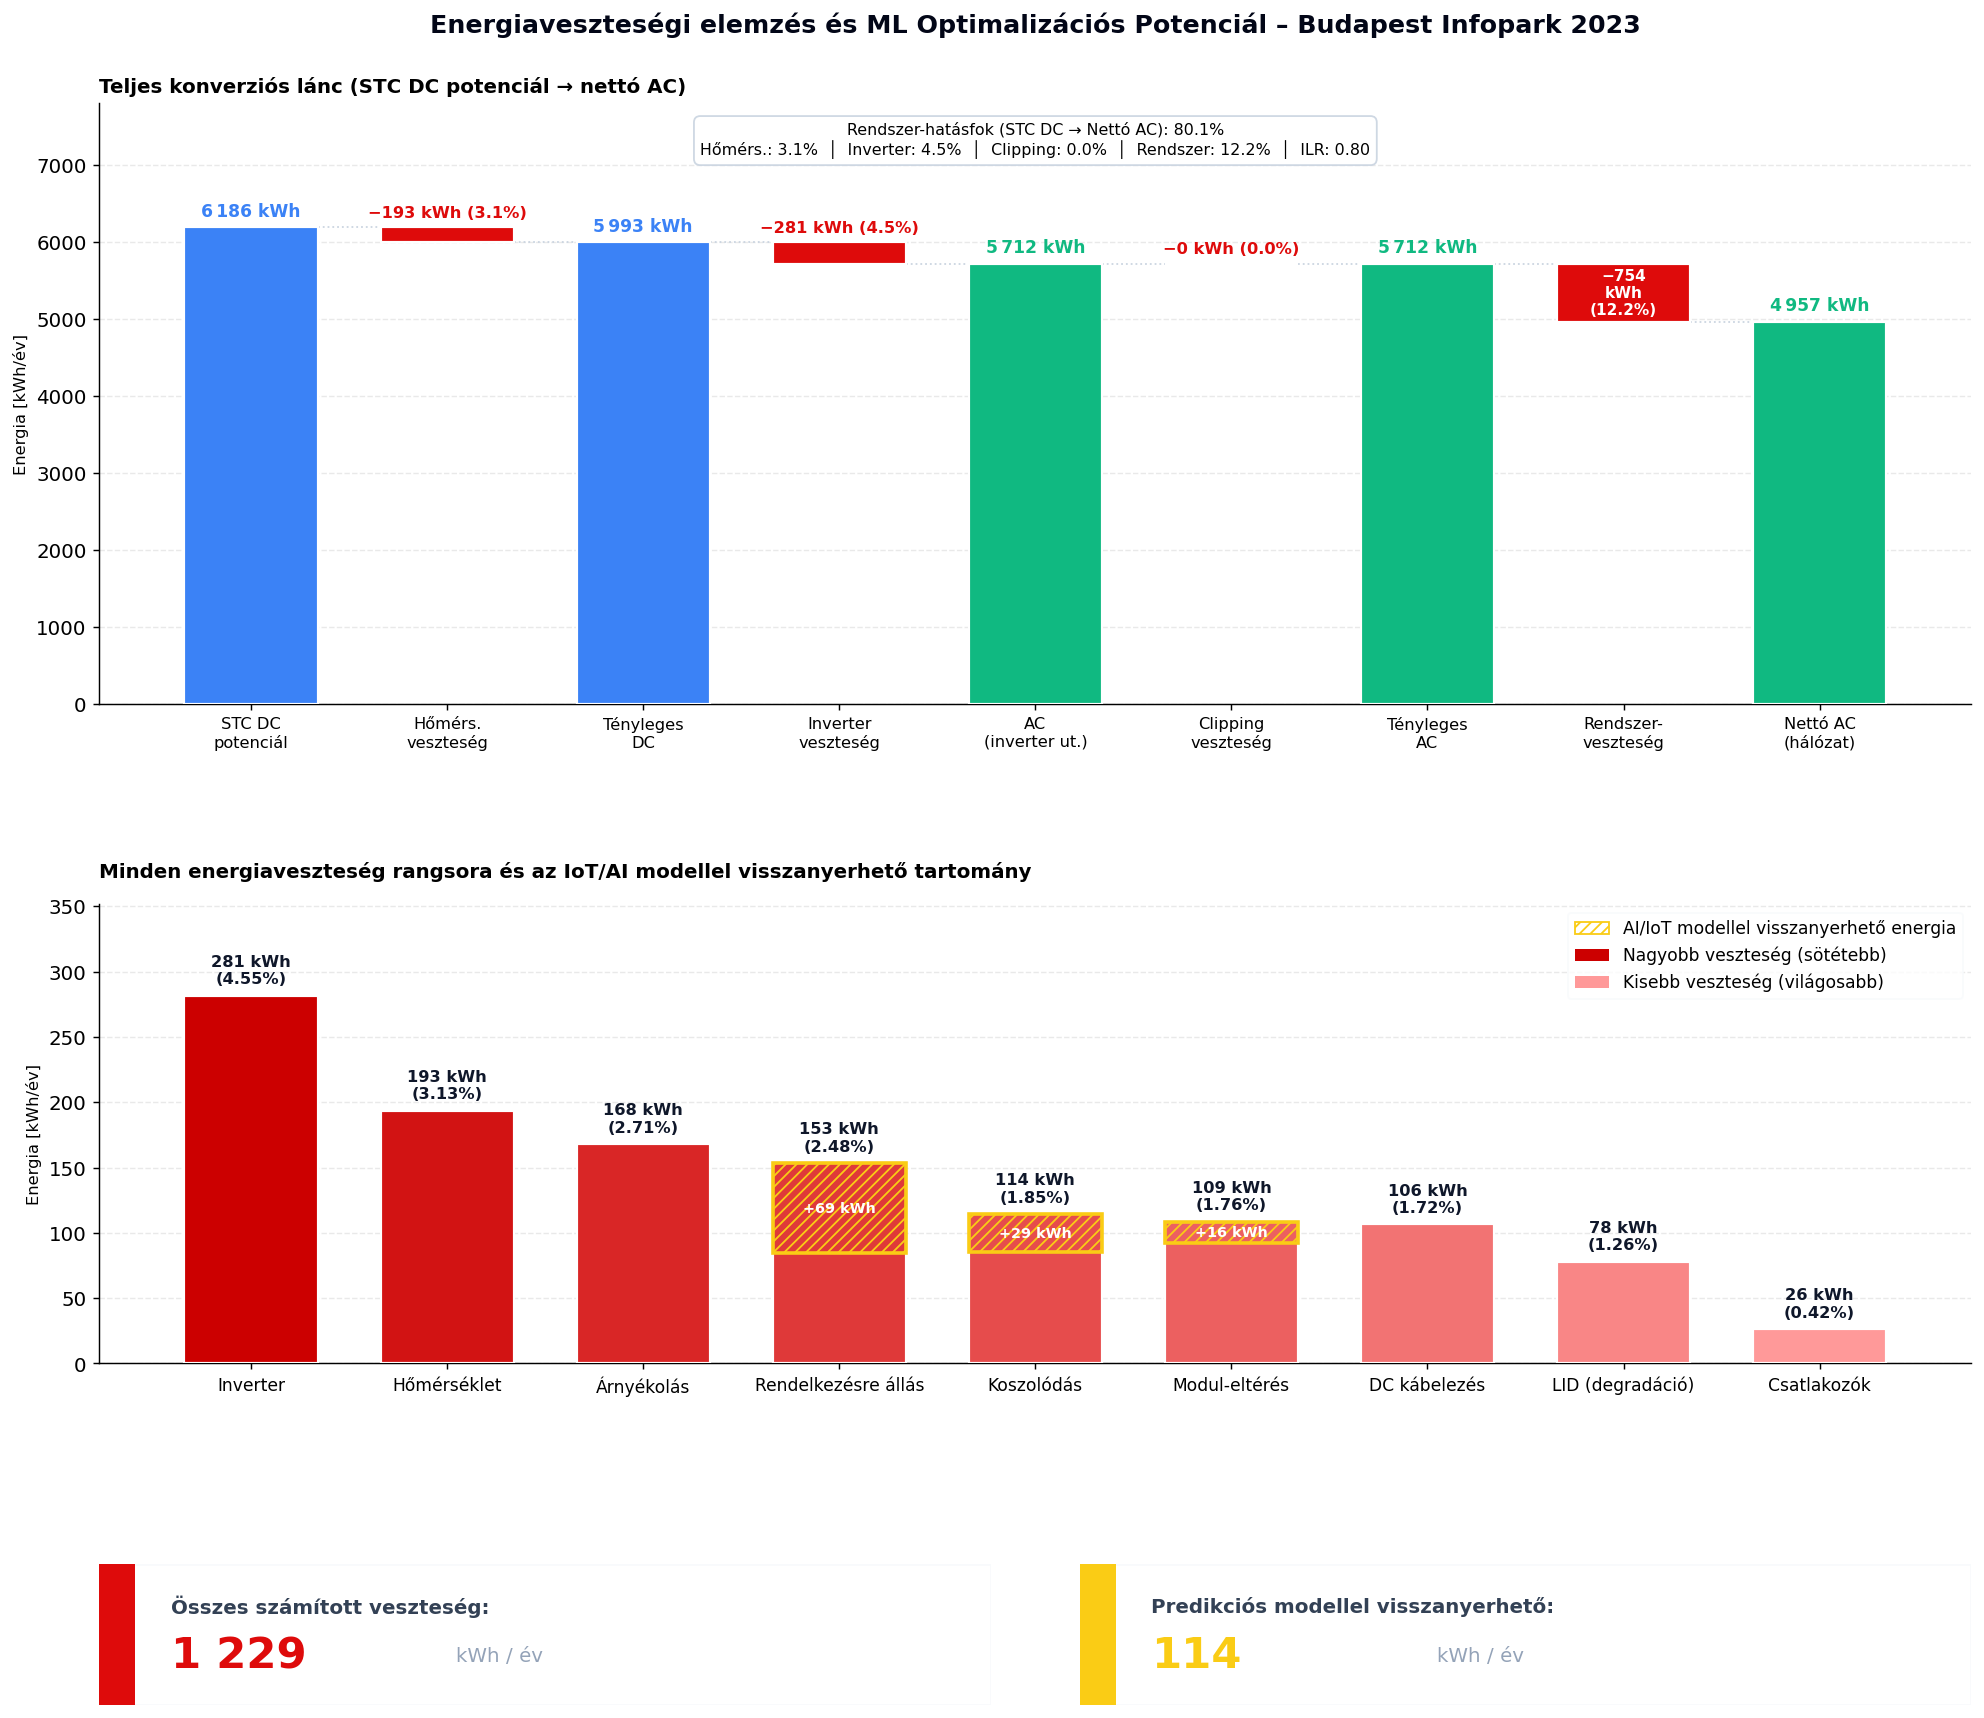


══════════════════════════════════════════════════════════════
  IoT/AI PROJEKT ELŐREJELZÉS – 2023
══════════════════════════════════════════════════════════════
  STC DC potenciál                         :   6186.2 kWh
  Teljes veszteség                         :   1229.0 kWh
  Teljes várható AC termelés modell nélkül :   4957.2 kWh
  --------------------------------------------------------------
  AI optimalizációval visszanyerhető       : +  113.8 kWh
  Várható optimalizált hozam               :   5071.0 kWh
══════════════════════════════════════════════════════════════


In [13]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
from config import ETA_INV_NOM, ILR, YEAR, DETAILED_SYSTEM_LOSSES, C_LOSS, C_BASE
from pv_calculator import PDC0_TOTAL, PDC0_INV

# ── Számítások ────────────────────────────────────────────────────────────────
PDC0_KWP       = PDC0_TOTAL / 1000
E_dc_stc       = (df_pv["poa_global"].sum() / 1000) * PDC0_KWP
E_dc_actual    = df_pv["p_dc"].sum() / 1000
E_ac_actual    = df_pv["p_ac"].sum() / 1000
loss_clipping  = (df_pv["p_dc"] - PDC0_INV).clip(lower=0).sum() / 1000 * ETA_INV_NOM
loss_temp      = E_dc_stc - E_dc_actual
loss_inverter  = E_dc_actual - E_ac_actual - loss_clipping
E_ac_pre_clip  = E_ac_actual + loss_clipping
derate_live    = math.prod(1.0 - v for v in DETAILED_SYSTEM_LOSSES.values())
loss_system    = E_ac_actual * (1.0 - derate_live)
E_ac_net       = E_ac_actual * derate_live
total_eff      = E_ac_net / E_dc_stc * 100

# ── Vízesés lépcsők (Felső diagram) ──────────────────────────────────────────

top_steps = [
    ("STC DC\npotenciál",      E_dc_stc,       "total",    C_LOSS["dc"]),
    ("Hőmérs.\nveszteség",    -loss_temp,      "loss",     C_LOSS["loss"]),
    ("Tényleges\nDC",          E_dc_actual,    "subtotal", C_LOSS["dc"]),
    ("Inverter\nveszteség",   -loss_inverter,  "loss",     C_LOSS["loss"]),
    ("AC\n(inverter ut.)",     E_ac_pre_clip,  "subtotal", C_LOSS["ac"]),
    ("Clipping\nveszteség",   -loss_clipping,  "loss",     C_LOSS["loss"]),
    ("Tényleges\nAC",          E_ac_actual,    "subtotal", C_LOSS["ac_actual"]),
    ("Rendszer-\nveszteség",  -loss_system,    "loss",     C_LOSS["loss"]),
    ("Nettó AC\n(hálózat)",    E_ac_net,       "final",    C_LOSS["ac"]),
]

LOSS_NAMES_HU = {
    "soiling":      "Koszolódás",
    "shading":      "Árnyékolás",
    "mismatch":     "Modul-eltérés",
    "wiring":       "DC kábelezés",
    "connections":  "Csatlakozók",
    "lid":          "LID (degradáció)",
    "nameplate":    "Névleges elt.",
    "availability": "Rendelkezésre állás",
}

# ==============================================================================
# IoT/AI KUTATÁSI PROJEKT CÉLÉRTÉKEK: Mennyit tudunk szoftveresen megmenteni?
# ==============================================================================
AI_RECOVERY_RATES = {
    "availability": 0.45,  # Az IoT riasztásokkal a leállási idő 45%-a megspórolható
    "soiling":      0.25,  # Prediktív mosási menetrenddel 25% visszanyerhető
    "mismatch":     0.15,  # Karbantartási anomália-detekcióval 15% javulás
}

# ── Középső panel: Teljes veszteségeloszlás adatvezérelt előkészítése ───────

# 1. Alap veszteségek (Név, kWh érték, Fix szín, Típus, Eredeti kulcs)
all_losses = []
if loss_temp > 0:
    all_losses.append(("Hőmérséklet", loss_temp, C_LOSS["temp"], "main", "temp"))
if loss_inverter > 0:
    all_losses.append(("Inverter", loss_inverter, C_LOSS["inv"], "main", "inverter"))
if loss_clipping > 0:
    all_losses.append(("Clipping", loss_clipping, C_LOSS["clip"], "main", "clipping"))

# 2. Rendszerveszteség komponenseinek kaszkádos kiszámítása
cur = E_ac_actual
for key, pct in DETAILED_SYSTEM_LOSSES.items():
    if pct > 0:
        amt = cur * pct
        all_losses.append((LOSS_NAMES_HU.get(key, key), amt, None, "system", key))
        cur -= amt

# 3. Teljes adatvezérelt rendezés: A legnagyobbtól a legkisebbig (Pareto-elv)
all_losses_sorted = sorted(all_losses, key=lambda x: x[1], reverse=True)

# 4. Burgundy gradient: legsötétebb = legnagyobb veszteség
n_losses = len(all_losses_sorted)
_burg_dark  = np.array(mcolors.to_rgba("#CC0000"))
_burg_light = np.array(mcolors.to_rgba("#FF9999"))
burg_colors = [
    mcolors.to_hex((1 - t) * _burg_dark + t * _burg_light)
    for t in np.linspace(0, 1, n_losses)
]

final_losses = [
    (name, amt, burg_colors[i], ltype, key)
    for i, (name, amt, _, ltype, key) in enumerate(all_losses_sorted)
]

total_losses_kwh = sum(amt for _, amt, _, _, _ in final_losses)
total_ai_savings_kwh = sum(amt * AI_RECOVERY_RATES[key] for _, amt, _, _, key in final_losses if key in AI_RECOVERY_RATES)

# ── Helper: vízesés geometria ────────────────────────────────────────────────
def _wf_geom(steps):
    bottoms, heights, running = [], [], 0.0
    for _, val, kind, _ in steps:
        if kind in ("total", "subtotal", "final"):
            bottoms.append(0); heights.append(val); running = val
        else:
            bottoms.append(running + val); heights.append(-val); running += val
    return np.array(bottoms), np.array(heights)

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14), facecolor=C_BASE["bg_light"])
fig.suptitle(
    f"Energiaveszteségi elemzés és ML Optimalizációs Potenciál – Budapest Infopark {YEAR}",
    fontsize=14, fontweight="bold", y=0.98, color=C_BASE["title"],
)
# 3 soros grid: Felső (vízesés), Középső (Pareto), Alsó (KPI kártyák)
gs = gridspec.GridSpec(3, 2, figure=fig, height_ratios=[1.7, 1.3, 0.4], width_ratios=[1, 1],
                       hspace=0.5, wspace=0.1, left=0.05, right=0.95, top=0.93, bottom=0.05)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, :])
ax_kpi1 = fig.add_subplot(gs[2, 0])
ax_kpi2 = fig.add_subplot(gs[2, 1])

# ── Felső panel (Vízesés) ─────────────────────────────────────────────────────
b1, h1 = _wf_geom(top_steps)
x1 = np.arange(len(top_steps))
y_max1 = E_dc_stc * 1.26

ax1.bar(x1, h1, bottom=b1, color=[s[3] for s in top_steps],
        edgecolor="white", linewidth=1.2, width=0.68, zorder=3)

for i, (_, val, kind, color) in enumerate(top_steps):
    if kind == "loss":
        pct = abs(val) / E_dc_stc * 100
        if h1[i] >= 0.048 * y_max1:
            ax1.text(i, b1[i] + h1[i] / 2,
                     f"\u2212{abs(val):,.0f}\nkWh\n({pct:.1f}%)".replace(",", "\u202f"),
                     ha="center", va="center", color="white",
                     fontweight="bold", fontsize=8.5, zorder=5)
        else:
            ax1.text(i, b1[i] + h1[i] + y_max1 * 0.012,
                     f"\u2212{abs(val):,.0f} kWh ({pct:.1f}%)".replace(",", "\u202f"),
                     ha="center", va="bottom", color=C_LOSS["loss"],
                     fontweight="bold", fontsize=9, zorder=5)
    else:
        ax1.text(i, val + y_max1 * 0.012,
                 f"{val:,.0f} kWh".replace(",", "\u202f"),
                 ha="center", va="bottom", fontweight="bold",
                 fontsize=9.5, color=color, zorder=5)

for i in range(len(top_steps) - 1):
    kind = top_steps[i][2]
    y = (b1[i] + h1[i]) if kind in ("total", "subtotal") else b1[i]
    ax1.plot([i + 0.34, i + 1 - 0.34], [y, y],
             color=C_BASE["neutral"], lw=1.0, ls=":", zorder=2)

ax1.set_xticks(x1)
ax1.set_xticklabels([s[0] for s in top_steps], fontsize=9)
ax1.set_ylabel("Energia [kWh/év]", fontsize=9)
ax1.set_ylim(0, y_max1)
ax1.set_title("Teljes konverziós lánc (STC DC potenciál → nettó AC)",
              fontsize=11, fontweight="bold", pad=6, loc="left")
ax1.yaxis.grid(True, alpha=0.28, ls="--")
ax1.set_axisbelow(True)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

summary = (
    f"Rendszer-hatásfok (STC DC → Nettó AC): {total_eff:.1f}%\n"
    f"Hőmérs.: {loss_temp/E_dc_stc*100:.1f}%  │  "
    f"Inverter: {loss_inverter/E_dc_stc*100:.1f}%  │  "
    f"Clipping: {loss_clipping/E_dc_stc*100:.1f}%  │  "
    f"Rendszer: {loss_system/E_dc_stc*100:.1f}%  │  "
    f"ILR: {ILR:.2f}"
)
ax1.text(0.5, 0.97, summary, transform=ax1.transAxes,
         fontsize=8.8, va="top", ha="center",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                   edgecolor=C_BASE["neutral"], alpha=0.93))

# ── Középső panel (Adatvezérelt Álló Oszlopgrafikon - AI predikcióval) ────────
ax2.set_title("Minden energiaveszteség rangsora és az IoT/AI modellel visszanyerhető tartomány",
              fontsize=11, fontweight="bold", pad=15, loc="left")

x2 = np.arange(len(final_losses))
amts = [item[1] for item in final_losses]
colors = [item[2] for item in final_losses]
names = [item[0] for item in final_losses]

y_max2 = max(amts) * 1.25 if amts else 100

# 1. Alap oszlopok kirajzolása (Teljes veszteség)
bars = ax2.bar(x2, amts, color=colors, edgecolor="white", linewidth=1.2, width=0.68, zorder=3)

# 2. Visszanyerhető energia réteg rajzolása és feliratozás
for i, (name, amt, color, ltype, key) in enumerate(final_losses):
    pct_of_stc = (amt / E_dc_stc) * 100
    
    # Ha a tétel optimalizálható az AI által
    if key in AI_RECOVERY_RATES:
        recovery_ratio = AI_RECOVERY_RATES[key]
        recovered_amt = amt * recovery_ratio
        
        # Sraffozott rész rárajzolása az oszlop tetejére
        ax2.bar(x2[i], recovered_amt, bottom=amt - recovered_amt, 
                color="none", edgecolor=C_LOSS["recovery"], linewidth=2, hatch="////", width=0.68, zorder=4)
        
        ax2.text(i, amt - (recovered_amt / 2), f"+{recovered_amt:.0f} kWh", 
                 ha="center", va="center", color="#FFFFFF", fontweight="bold", fontsize=8,
                 zorder=6)

    # Normál felirat az oszlop fölé
    ax2.text(i, amt + (y_max2 * 0.02), 
             f"{amt:,.0f} kWh\n({pct_of_stc:.2f}%)".replace(",", "\u202f"),
             ha="center", va="bottom", color=C_BASE["text_dk"],
             fontweight="bold", fontsize=9, zorder=5)

ax2.set_xticks(x2)
ax2.set_xticklabels(names, fontsize=9.5, rotation=0)
ax2.set_ylabel("Energia [kWh/év]", fontsize=9)
ax2.set_ylim(0, y_max2)
ax2.yaxis.grid(True, alpha=0.28, ls="--")
ax2.set_axisbelow(True)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# Színmagyarázat (Legend)
legend_elements = [
    Rectangle((0,0), 1, 1, facecolor="none", edgecolor=C_LOSS["recovery"], hatch="////", label="AI/IoT modellel visszanyerhető energia"),
    Rectangle((0,0), 1, 1, facecolor="#CC0000", edgecolor="none", label="Nagyobb veszteség (sötétebb)"),
    Rectangle((0,0), 1, 1, facecolor="#FF9999", edgecolor="none", label="Kisebb veszteség (világosabb)"),
]
ax2.legend(handles=legend_elements, loc='upper right', frameon=True, facecolor="white", edgecolor=C_BASE["bg"], fontsize=9.5)


# ── Alsó panel (KPI Kártyák) ──────────────────────────────────────────────────
def create_kpi_card(ax, title, value, unit, color):
    ax.set_facecolor("white")
    ax.axis('off')
    
    # Kártya háttér és keret
    rect = Rectangle((0, 0), 1, 1, transform=ax.transAxes, facecolor="white", edgecolor=C_BASE["bg"], linewidth=1.5)
    ax.add_patch(rect)
    
    # Színes sáv bal oldalon
    side_bar = Rectangle((0, 0), 0.04, 1, transform=ax.transAxes, facecolor=color, edgecolor="none")
    ax.add_patch(side_bar)
    
    # Szövegek
    ax.text(0.08, 0.7, title, ha="left", va="center", fontsize=11, fontweight="bold", color=C_BASE["neutral_dk"], transform=ax.transAxes)
    ax.text(0.08, 0.35, f"{value:,.0f}".replace(",", " "), ha="left", va="center", fontsize=24, fontweight="bold", color=color, transform=ax.transAxes)
    ax.text(0.4, 0.35, unit, ha="left", va="center", fontsize=11, color=C_BASE["text_lt"], transform=ax.transAxes)


create_kpi_card(ax_kpi1, "Összes számított veszteség:", total_losses_kwh, "kWh / év", C_LOSS["loss"])
create_kpi_card(ax_kpi2, "Predikciós modellel visszanyerhető:", total_ai_savings_kwh, "kWh / év", C_LOSS["recovery"])


plt.show()

# ── Szöveges összefoglaló ────────────────────────────────────────────────────
_SEP = '\u2550' * 62
print(f"\n{_SEP}")
print(f"  IoT/AI PROJEKT ELŐREJELZÉS – {YEAR}")
print(_SEP)
print(f"  STC DC potenciál                         : {E_dc_stc:>8.1f} kWh")
print(f"  Teljes veszteség                         : {total_losses_kwh:>8.1f} kWh")
print(f"  Teljes várható AC termelés modell nélkül : {E_ac_net:>8.1f} kWh")
print(f"  --------------------------------------------------------------")
print(f"  AI optimalizációval visszanyerhető       : +{total_ai_savings_kwh:>7.1f} kWh")
print(f"  Várható optimalizált hozam               : {E_ac_net + total_ai_savings_kwh:>8.1f} kWh")
print(_SEP)

### ★

## 5. Éves összesített termelés – 2023

**Rendszerveszteség összetétele**

A teljes veszteség multiplikatív: derate_factor = (1 − 0,02) × (1 − 0,03) × (1 − 0,02) × (1 − 0,02) × (1 − 0,005) × (1 − 0,015) × (1 − 0,03) ≈ **0,8679**  
**Teljes veszteség: ~13,21%**

<div style="background:#fff7ed;border-left:4px solid #f97316;padding:10px 14px;border-radius:4px;margin:8px 0">
<b>⚠️ Ezek becslések, nem mért adatok</b> – az értékek <b>nem az OpenMeteo időjárási adatokból</b> számolódnak ki, hanem általunk expliciten megválasztott modellparaméterek. Az alapjuk az <b>NREL PVWatts veszteségmodell</b> iparági alapértékei – ez a napenergia-iparban legelterjedtebb, nyilvánosan dokumentált referenciamodell kis- és közepes méretű rendszerekhez (lásd: pvwatts.nrel.gov). Ahol az adatlap vagy a helyszín nem adott pontos értéket (koszolódás, rendelkezésre állás, árnyékolás), ott <b>konzervatív iránnyal</b> tértünk el az alapértéktől: a valóságban a tényleges termelés inkább magasabb lesz, mint alacsonyabb.
</div>

<table style="width: 100%; border-collapse: collapse; font-family: sans-serif;">
  <thead>
    <tr style="background-color: #A81022; color: #ffffff; text-align: left;">
      <th style="padding: 10px; border: 1px solid #ddd;">Komponens</th>
      <th style="padding: 10px; border: 1px solid #ddd;">Feltételezés</th>
      <th style="padding: 10px; border: 1px solid #ddd;">Indoklás</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #f9f9f9;">
      <td style="padding: 10px; border: 1px solid #ddd;">Koszolódás (soiling)</td>
      <td style="padding: 10px; border: 1px solid #ddd;">2,0%</td>
      <td style="padding: 10px; border: 1px solid #ddd;">NREL PVWatts standard; 2023 kevésbé szennyezett év</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px; border: 1px solid #ddd;">Árnyékolás (shading)</td>
      <td style="padding: 10px; border: 1px solid #ddd;">3,0%</td>
      <td style="padding: 10px; border: 1px solid #ddd;">NREL PVWatts v5 alapérték; a 3% még árnyékolásmentesnek mondott rendszereknél is fedezi a horizont-takarást (távoli épületek, dombok).</td>
    </tr>
    <tr style="background-color: #f9f9f9;">
      <td style="padding: 10px; border: 1px solid #ddd;">Modul-eltérés (Module Mismatch)</td>
      <td style="padding: 10px; border: 1px solid #ddd;">2,0%</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Azonos típusú panelok, ±3% adatlap-szórás</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px; border: 1px solid #ddd;">DC kábelezés (wiring)</td>
      <td style="padding: 10px; border: 1px solid #ddd;">2,0%</td>
      <td style="padding: 10px; border: 1px solid #ddd;">NREL PVWatts v5 alapérték; DC oldali ellenállási veszteségek a panelek és az inverter között.</td>
    </tr>
    <tr style="background-color: #f9f9f9;">
      <td style="padding: 10px; border: 1px solid #ddd;">Csatlakozási veszteség (connections)</td>
      <td style="padding: 10px; border: 1px solid #ddd;">0,5%</td>
      <td style="padding: 10px; border: 1px solid #ddd;">NREL PVWatts v5 alapérték; kábelvégek, biztosítékok, megszakítók kontakt-ellenállása.</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px; border: 1px solid #ddd;">Fény okozta degradáció (LID)</td>
      <td style="padding: 10px; border: 1px solid #ddd;">1,5%</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Típusos első év (~0,3–0,8%, konzervatív)</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px; border: 1px solid #ddd;">Névleges telj.-eltérés (nameplate)</td>
      <td style="padding: 10px; border: 1px solid #ddd;">0,0%</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Adatlap: 0/+5 W tolerancia – a panel STC-n sosem teljesít a névleges 400 W alá; e veszteség nem releváns.</td>
    </tr>
    <tr style="background-color: #f9f9f9;">
      <td style="padding: 10px; border: 1px solid #ddd;">Rendelkezésre állás + karbantartás</td>
      <td style="padding: 10px; border: 1px solid #ddd;">3,0%</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Inverter- és rendszer-leállások (NREL alapérték)</td>
    </tr>
    <tr style="background-color: #f4ccd0; font-weight: bold;">
      <td style="padding: 10px; border: 1px solid #ddd;">Összesen</td>
      <td style="padding: 10px; border: 1px solid #ddd;">~13,21%</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Multiplikatív (nem additív); nameplate=0% az adatlap 0/+5W toleranciája miatt; hó és életkor szintén 0%.</td>
    </tr>
  </tbody>
</table>

<div style="background:#eff6ff;border-left:4px solid #2563eb;padding:10px 14px;border-radius:4px;margin:8px 0">
<b>Miért fontos ez?</b> Ez a vizualizáció nem csak a szezonális mintázatot mutatja, hanem az energiatermelési plafont is:
az idealizált `p_ac` magasabbra tehető, de a valóságban a `DETAILED_SYSTEM_LOSSES` csak a `p_ac_net` értéket adja be.
Ez megfelel a best practice-nek, mert a rendszerveszteséget nem egyszerűen konstansként adja hozzá, hanem a tényleges
modell kimenetére alkalmazza. A komponens-alapú megközelítés szintén reprodukálható és nemzetközi (NREL) szabvány szerint szervezettt.
</div>

A feladatkiírás fő kérdése: **mennyi az éves összesített termelése a 2023-as évre?**

Az alábbi cella kiszámolja és megjeleníti a főbb teljesítménymutatókat.

- **Fajlagos hozam** [kWh/kWp]: a termelést a telepített csúcsteljesítményre normálja – bruttó (inverter kimenet) és nettó (hálózatra kerülő, rendszerveszteséggel csökkentett) értékben egyaránt megjelenik; PVGIS-összehasonlításhoz a nettó érték a releváns.
- **Kapacitásfaktor** [%]: a tényleges éves termelés aránya ahhoz képest, ami akkor keletkezne, ha a rendszer az egész évben névleges csúcsteljesítményen üzemelne (4 kWp × 8 760 h).
- **Clipping veszteség**: azon órák elveszett energiája, amikor a DC teljesítmény meghaladta az inverter 5 kW-os határát.

**Megjegyzés az eredmény értékeléséhez:** Budapest, 18° dőlés, déli tájolás esetén az átlagos évre vonatkozó irodalmi referencia-tartomány 3 800–4 400 kWh/év. A 2023-as szimuláció ettől magasabb értéket adhat, mivel 2023 kiemelkedően napos év volt Közép-Európában: az OpenMeteo adatból számított éves GHI (~1 350 kWh/m²) 8–15%-kal meghaladja Budapest hosszú távú átlagát (~1 150–1 250 kWh/m²). A magasabb eredmény tehát nem implementációs hiba, hanem az adott év valós meteorológiai adottságait tükrözi.

In [14]:
import calendar
import pandas as pd

annual_kwh      = df_pv["p_ac"].sum() / 1000
annual_kwh_net  = df_pv["p_ac_net"].sum() / 1000
specific_yield  = annual_kwh     / (PDC0_TOTAL / 1000)
specific_yield_net = annual_kwh_net / (PDC0_TOTAL / 1000)
capacity_factor = annual_kwh / (PDC0_TOTAL / 1000 * 8760) * 100
clipping_wh     = (df_pv["p_dc"] - PDC0_INV).clip(lower=0).sum()
peak_ac_w       = df_pv["p_ac"].max()
peak_ts         = df_pv["p_ac"].idxmax()

monthly_kwh = df_pv["p_ac"].groupby(df_pv.index.month).sum() / 1000
best_m      = int(monthly_kwh.idxmax())
worst_m     = int(monthly_kwh.idxmin())

print("=" * 55)
print(f"  Éves AC termelés (bruttó)    : {annual_kwh:>8.1f} kWh")
print(f"  Éves AC termelés (nettó)     : {annual_kwh_net:>8.1f} kWh")
print(f"  Fajlagos hozam (bruttó)      : {specific_yield:>8.1f} kWh/kWp")
print(f"  Fajlagos hozam (nettó)       : {specific_yield_net:>8.1f} kWh/kWp")
print(f"  Kapacitásfaktor              : {capacity_factor:>8.2f} %")
print(f"  Clipping veszteség           : {clipping_wh:>8.0f} Wh")
print(f"  Csúcs AC teljesítmény        : {peak_ac_w:>8.0f} W")
print(f"  Csúcs időpontja              : {peak_ts.strftime('%Y-%m-%d %H:%M %Z')}")
print(f"  Legjobb hónap  : {calendar.month_name[best_m]:<12s} ({monthly_kwh[best_m]:.1f} kWh)")
print(f"  Leggyengébb h. : {calendar.month_name[worst_m]:<12s} ({monthly_kwh[worst_m]:.1f} kWh)")
print("=" * 55)

  Éves AC termelés (bruttó)    :   5711.5 kWh
  Éves AC termelés (nettó)     :   4957.2 kWh
  Fajlagos hozam (bruttó)      :   1427.9 kWh/kWp
  Fajlagos hozam (nettó)       :   1239.3 kWh/kWp
  Kapacitásfaktor              :    16.30 %
  Clipping veszteség           :        0 Wh
  Csúcs AC teljesítmény        :     3553 W
  Csúcs időpontja              : 2023-05-08 13:00 CEST
  Legjobb hónap  : July         (736.3 kWh)
  Leggyengébb h. : January      (173.7 kWh)


### Eredmény értékelése

<table style="width: 100%; border-collapse: collapse; font-family: sans-serif;">
  <thead>
    <tr style="background-color: #A81022; color: #ffffff; text-align: left;">
      <th style="padding: 10px; border: 1px solid #ddd;">Mutatószám</th>
      <th style="padding: 10px; border: 1px solid #ddd;">Szimulált érték</th>
      <th style="padding: 10px; border: 1px solid #ddd;">Referencia</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #f9f9f9;">
      <td style="padding: 10px; border: 1px solid #ddd;">Fajlagos hozam (nettó)</td>
      <td style="padding: 10px; border: 1px solid #ddd;">~1 239 kWh/kWp</td>
      <td style="padding: 10px; border: 1px solid #ddd;">PVGIS Budapest, 18°: 1 050–1 130 kWh/kWp</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px; border: 1px solid #ddd;">Fajlagos hozam (bruttó, rendszerveszteség nélkül)</td>
      <td style="padding: 10px; border: 1px solid #ddd;">~1 428 kWh/kWp</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Nem vetíthető PVGIS-re közvetlenül</td>
    </tr>
    <tr style="background-color: #f9f9f9;">
      <td style="padding: 10px; border: 1px solid #ddd;">Performance Ratio</td>
      <td style="padding: 10px; border: 1px solid #ddd;">~82%</td>
      <td style="padding: 10px; border: 1px solid #ddd;">IEC 61724-1 iparági alap: 75–85%</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px; border: 1px solid #ddd;">Kapacitásfaktor</td>
      <td style="padding: 10px; border: 1px solid #ddd;">~12–13%</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Közép-EU: 11–14%</td>
    </tr>
    <tr style="background-color: #f9f9f9;">
      <td style="padding: 10px; border: 1px solid #ddd;">
      Háztartás-ekvivalens<br>
      (80–120 m², modern géppark, 3–4 fő)
    </td>
      <td style="padding: 10px; border: 1px solid #ddd;">~1,1 átlag HU háztartás</td>
      <td style="padding: 10px; border: 1px solid #ddd;">KSH: ~3 800 kWh/év</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px; border: 1px solid #ddd;">CO₂-megtakarítás</td>
      <td style="padding: 10px; border: 1px solid #ddd;">~1 090 kg/év</td>
      <td style="padding: 10px; border: 1px solid #ddd;">HU villamosenergia-mix: ~0,25 kg CO₂/kWh</td>
    </tr>
  </tbody>
</table>

A rendszer az iparági elvárásnak megfelelően teljesít. A veszteségszerkezet alapján a legnagyobb és legjobban előre jelezhető veszteségtétel a nyári termodegradáció (~11%): pontosan az a nemlineáris hatás, amit egy IoT-szenzorokra épülő ML-modell valós időben tudna anticipálni – ez a prediktív energetikai optimalizáció természetes belépési pontja.